## Seuls les clients considérés comme actifs au moins 1 fois sur les 6 mois, hors clientèle atypique, sont étudiés ici soit 28 851 (dataset cleaned4 : comptes inactifs et 4 paiements supérieurs à 1 000 000 NT$ retirés, plafonds > 500 000 écartés).

In [117]:
import pandas as pd
import os

current_dir = os.path.abspath('.')
root_dir = os.path.dirname(current_dir) 
file_path = os.path.join(root_dir, 'data', 'cleaned4_creditcard.csv')
    
# Charger le CSV dans un DataFrame
df = pd.read_csv(file_path)


#### Toutes les colonnes créées dans mon EDA utilisées par Streamlit doivent être créées ci dessous avant l'enregistrement du dataset

#### création des colonnes ratio_BILL_LIMITn = BILL_AMTn / LIMIT_BAL avec borne base à 0 pour les encours négatifs et limité à 200% pour éviter les distorsions dans l'EDA et le ML

In [118]:
# Création des colonnes de ratio d'utilisation du plafond
import pandas as pd
import numpy as np

# Vérification rapide des colonnes BILL_AMT existantes
bill_cols = [col for col in df.columns if col.startswith('BILL_AMT')]
print(f"Colonnes BILL_AMT trouvées : {bill_cols}")

# Boucle pour créer les 6 nouvelles colonnes de ratio
for i in range(1, 7):
    # Calcul du ratio avec limitation à 200%
    ratio_col = np.minimum((np.maximum(df[f'BILL_AMT{i}'], 0) / df['LIMIT_BAL']) * 100, 200)
    df[f'ratio_BILL_LIMIT{i}'] = ratio_col

# Affichage des premières lignes pour inspection
# On filtre pour ne voir que les colonnes BILL_AMT et ratio_BILL_LIMIT concernées
cols_to_show = bill_cols + [f'ratio_BILL_LIMIT{n}' for n in range(1, 7)] + ['LIMIT_BAL']
pd.option_context('display.max_columns', None, 'display.width', 1000)
print("\n--- Aperçu des nouveaux ratios ---")
df[cols_to_show].head(10)


Colonnes BILL_AMT trouvées : ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

--- Aperçu des nouveaux ratios ---


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6,LIMIT_BAL
0,3913,3102,689,0,0,0,19.565000,15.510000,3.445000,0.000000,0.000000,0.000000,20000
1,2682,1725,2682,3272,3455,3261,2.235000,1.437500,2.235000,2.726667,2.879167,2.717500,120000
2,29239,14027,13559,14331,14948,15549,32.487778,15.585556,15.065556,15.923333,16.608889,17.276667,90000
3,46990,48233,49291,28314,28959,29547,93.980000,96.466000,98.582000,56.628000,57.918000,59.094000,50000
4,8617,5670,35835,20940,19146,19131,17.234000,11.340000,71.670000,41.880000,38.292000,38.262000,50000
5,64400,57069,57608,19394,19619,20024,128.800000,114.138000,115.216000,38.788000,39.238000,40.048000,50000
6,367965,412023,445007,542653,483003,473944,73.593000,82.404600,89.001400,108.530600,96.600600,94.788800,500000
7,11876,380,601,221,-159,567,11.876000,0.380000,0.601000,0.221000,0.000000,0.567000,100000
8,11285,14096,12108,12211,11793,3719,8.060714,10.068571,8.648571,8.722143,8.423571,2.656429,140000
9,0,0,0,0,13007,13912,0.000000,0.000000,0.000000,0.000000,65.035000,69.560000,20000


In [119]:
# Les colonnes ratio_PAY_BILLn viennent de cleaned3 (définition unique créée dans 02_01_nettoyage) :
# PAY_AMTn / BILL_AMT(n+1) en %, écrêté entre 0 et 200, 100 % si aucune facture n'était exigible.
# Elles ne sont pas recalculées ici, pour garder la même définition dans l'EDA, Streamlit et le ML.
ratio_pay_cols = [f'ratio_PAY_BILL{n}' for n in range(1, 6)]
print(df[ratio_pay_cols].describe().round(2))


def ratios_affichables(d, cols):
    """Ratios de paiement à afficher dans les graphiques : uniquement quand une facture était exigible
    (BILL_AMT(n+1) > 0). La colonne ratio_PAY_BILLn garde sa définition unique (100 % sans facture
    exigible, voir docs/colonnes_creees.md) : ce filtre ne sert qu'à l'affichage."""
    out = d[cols].copy()
    for col in cols:
        n = int(col.replace('ratio_PAY_BILL', ''))
        out[col] = out[col].where(d[f'BILL_AMT{n + 1}'] > 0)
    return out


       ratio_PAY_BILL1  ratio_PAY_BILL2  ratio_PAY_BILL3  ratio_PAY_BILL4  \
count         28851.00         28851.00         28851.00         28851.00   
mean             39.25            40.22            39.31            39.27   
std              45.36            45.84            46.20            46.49   
min               0.00             0.00             0.00             0.00   
25%               4.42             4.41             3.75             3.63   
50%               9.34             9.49             7.83             7.11   
75%             100.00           100.00           100.00           100.00   
max             200.00           200.00           200.00           200.00   

       ratio_PAY_BILL5  
count         28851.00  
mean             42.01  
std              46.94  
min               0.00  
25%               3.78  
50%               8.11  
75%             100.00  
max             200.00  


In [120]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_PAY_BILL1', 'ratio_PAY_BILL2', 'ratio_PAY_BILL3',
       'ratio_PAY_BILL4', 'ratio_PAY_BILL5', 'ratio_BILL_LIMIT1',
       'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4',
       'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6'],
      dtype='str')

#### Copie du dataset CSV pour le dépot Git et Streamlit

In [121]:
# SYNCHRONISATION DU CSV POUR STREAMLIT
# 2. Répertoire et nom de destination ciblés
target_dir = os.path.join(root_dir, 'data/csv_streamlit')
target_file = os.path.join(target_dir, 'dataset_streamlit.csv')

# 3. Créer le dossier de destination s'il n'existe pas encore
os.makedirs(target_dir, exist_ok=True)

# 4. Exporter le DataFrame enrichi
df.to_csv(target_file, index=False, encoding="utf-8")
print(f"DataFrame exporté avec succès vers : {target_file}")

DataFrame exporté avec succès vers : c:\Users\johan\VS Code Wild 2\PROJET_DEFAULT_CREDIT_CARD_ML\data/csv_streamlit\dataset_streamlit.csv


In [122]:
df = df.set_index('ID')
print(df.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm', 'ratio_PAY_BILL1', 'ratio_PAY_BILL2', 'ratio_PAY_BILL3', 'ratio_PAY_BILL4', 'ratio_PAY_BILL5', 'ratio_BILL_LIMIT1', 'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4', 'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6']


In [123]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,ratio_PAY_BILL2,ratio_PAY_BILL3,ratio_PAY_BILL4,ratio_PAY_BILL5,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6
count,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,...,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000
mean,162940.268275,1.602891,1.849537,1.559842,35.416797,-0.119476,-0.072441,-0.104849,-0.161173,-0.208416,...,40.218741,39.307768,39.269998,42.007824,43.765052,42.483930,40.502543,37.201205,34.471693,32.993875
std,124911.013950,0.489307,0.742375,0.521544,9.212084,1.133959,1.168189,1.169512,1.143629,1.107995,...,45.841363,46.196147,46.492349,46.940528,40.409015,39.784494,38.715731,36.558641,34.814705,34.463329
min,10000.000000,1.000000,1.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,4.408874,3.747475,3.629109,3.782738,2.972867,2.514900,2.238985,2.057321,1.580238,1.153636
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.493023,7.825951,7.110062,8.112589,34.981500,33.200000,30.473000,27.192000,23.968000,20.859231
75%,230000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.000000,100.000000,100.000000,100.000000,84.329333,82.122500,77.366500,68.427885,61.370000,59.383000
max,500000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000


In [124]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,ratio_PAY_BILL2,ratio_PAY_BILL3,ratio_PAY_BILL4,ratio_PAY_BILL5,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,100.000000,100.000000,100.000000,100.000000,19.565000,15.510000,3.445000,0.000000,0.000000,0.000000
2,120000,2,2,2,26,-1,2,0,0,0,...,37.285608,30.562347,28.943560,0.000000,2.235000,1.437500,2.235000,2.726667,2.879167,2.717500
3,90000,2,2,2,34,0,0,0,0,0,...,11.062763,6.977880,6.689858,6.431282,32.487778,15.585556,15.065556,15.923333,16.608889,17.276667
4,50000,2,2,1,37,0,0,0,0,0,...,4.096082,4.238186,3.798474,3.617965,93.980000,96.466000,98.582000,56.628000,57.918000,59.094000
5,50000,1,2,1,57,-1,0,-1,0,0,...,102.360820,47.755492,47.007208,3.601485,17.234000,11.340000,71.670000,41.880000,38.292000,38.262000


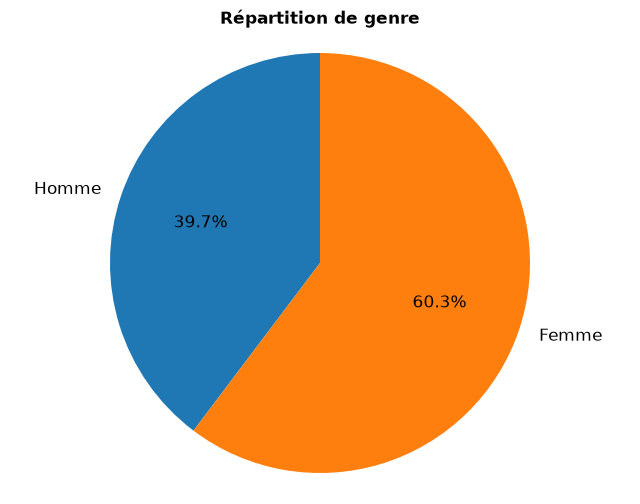

In [125]:
import matplotlib.pyplot as plt
import pandas as pd


# 1. Comptage des occurrences
sex_counts = df['SEX'].value_counts().sort_index()

# 2. Définition des étiquettes pour correspondre à tes codes
labels_map = {1: 'Homme', 2: 'Femme'}

# On applique le mapping aux index du comptage pour la légende
labels = [labels_map.get(code, str(code)) for code in sex_counts.index]

# 3. Création du graphique
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    sex_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#1f77b4', '#ff7f0e'],  # Bleu pour Homme, Orange pour Femme (exemple)
    textprops={'fontsize': 12}
)

plt.title('Répartition de genre', fontweight='bold')
plt.axis('equal')  # Assure que le diagramme est un cercle
plt.show()



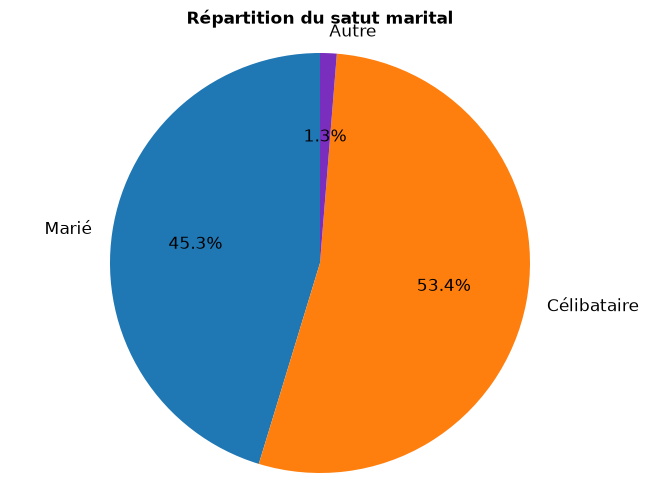

In [126]:
import matplotlib.pyplot as plt
import pandas as pd

code_to_label_map = {1:'Marié', 2: 'Célibataire', 3 : 'Autre'}

# 1. Comptage des occurrences
cat_counts = df['MARRIAGE'].value_counts().sort_index()

# 2. Préparation des labels et couleurs
# On garde l'ordre des index (codes) pour la légende et le diagramme
codes = list(cat_counts.index)
labels = [code_to_label_map.get(code, f"Code {code}") for code in codes]

# Palette de couleurs pré-définie pour être cohérent
colors = ['#1f77b4', '#ff7f0e', "#792ebe"]

# 3. Création du graphique
plt.figure(figsize=(8, 6))

wedges, texts, autotexts = plt.pie(
    cat_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors, 
    textprops={'fontsize': 12}
)

plt.title(f'Répartition du satut marital', fontweight='bold')
plt.axis('equal')
plt.show()



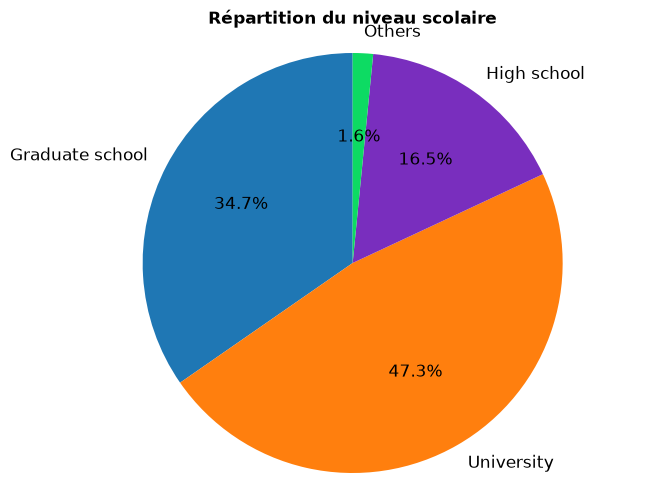

In [127]:
import matplotlib.pyplot as plt
import pandas as pd

code_to_label_map = {1 : 'Graduate school', 2 : 'University', 3 : 'High school', 4 : 'Others'}

# 1. Comptage des occurrences
cat_counts = df['EDUCATION'].value_counts().sort_index()

# 2. Préparation des labels et couleurs
# On garde l'ordre des index (codes) pour la légende et le diagramme
codes = list(cat_counts.index)
labels = [code_to_label_map.get(code, f"Code {code}") for code in codes]

# Palette de couleurs pré-définie pour être cohérent
colors = ['#1f77b4', '#ff7f0e', "#792ebe", "#0ddb63"]

# 3. Création du graphique
plt.figure(figsize=(8, 6))

wedges, texts, autotexts = plt.pie(
    cat_counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors, 
    textprops={'fontsize': 12},
)

plt.title(f'Répartition du niveau scolaire', fontweight='bold')
plt.axis('equal')
plt.show()



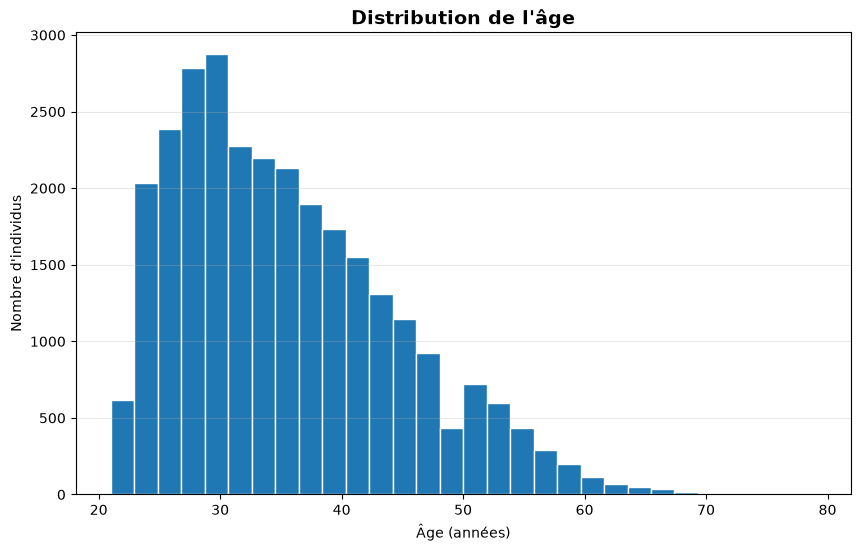

In [128]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 6))

# On trace l'histogramme
# bins=20 : divise la plage de valeurs en 20 intervals (on peut ajuster)
# color='#1f77b4' : couleur bleu standard matplotlib
plt.hist(df['AGE'], bins=30, color='#1f77b4', edgecolor='white')

plt.title(f"Distribution de l'âge", fontweight='bold', fontsize=14)
plt.xlabel("Âge (années)")
plt.ylabel("Nombre d'individus")

plt.grid(axis='y', alpha=0.3)
plt.show()


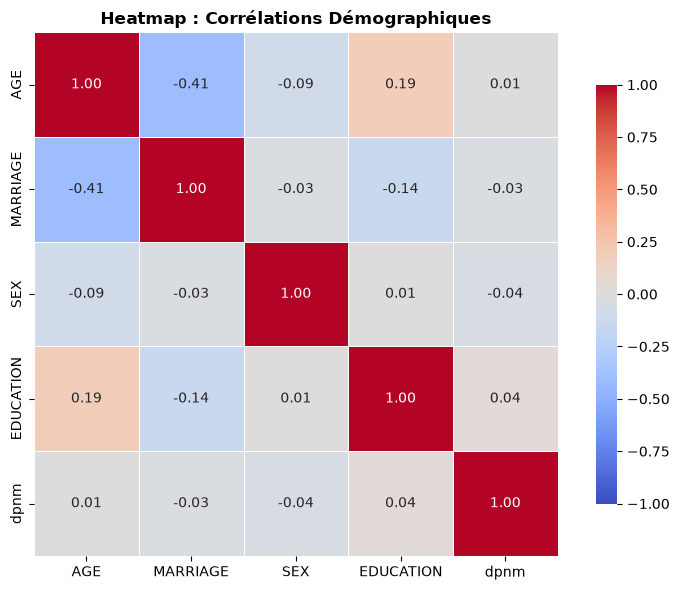

In [129]:
import seaborn as sns

# 1. Sélection des colonnes
cols = ['AGE', 'MARRIAGE', 'SEX', 'EDUCATION', 'dpnm']
df_corr = df[cols]

# 2. Calcul de la matrice complète (sans masquage)
corr_matrix = df_corr.corr(method='pearson')

# 3. Affichage du Heatmap COMPLET
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,       # Affiche les chiffres
    fmt=".2f",        # Format à 2 décimales
    cmap='coolwarm',  # Palette Rouge/Blanc/Bleu (positif/négatif)
    vmin=-1, vmax=1,
    square=True,      # Cases carrées
    linewidths=.5,    # Lignes fines entre les cases pour la lisibilité
    cbar_kws={"shrink": .8}
)

plt.title('Heatmap : Corrélations Démographiques', fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation**  
pas de corrélation évidente entre les données démographiques et le défaut de paiement  
attention aux valeurs catégorielles qui peuvent ne pas supporter une hiérarchie

In [130]:
# Je crée des buckets d'âges en maintenant une population suffisamment représentative dans chacun
age_bins = [20, 25, 30, 35, 40, 50, 80] 
age_labels = ['21-25', '26-30', '31-35', '36-40', '41-50', '51+']

# On vérifie si la colonne existe déjà, sinon on la crée
if 'AGE_BUCKET' not in df.columns:
    df['AGE_BUCKET'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, include_lowest=True)

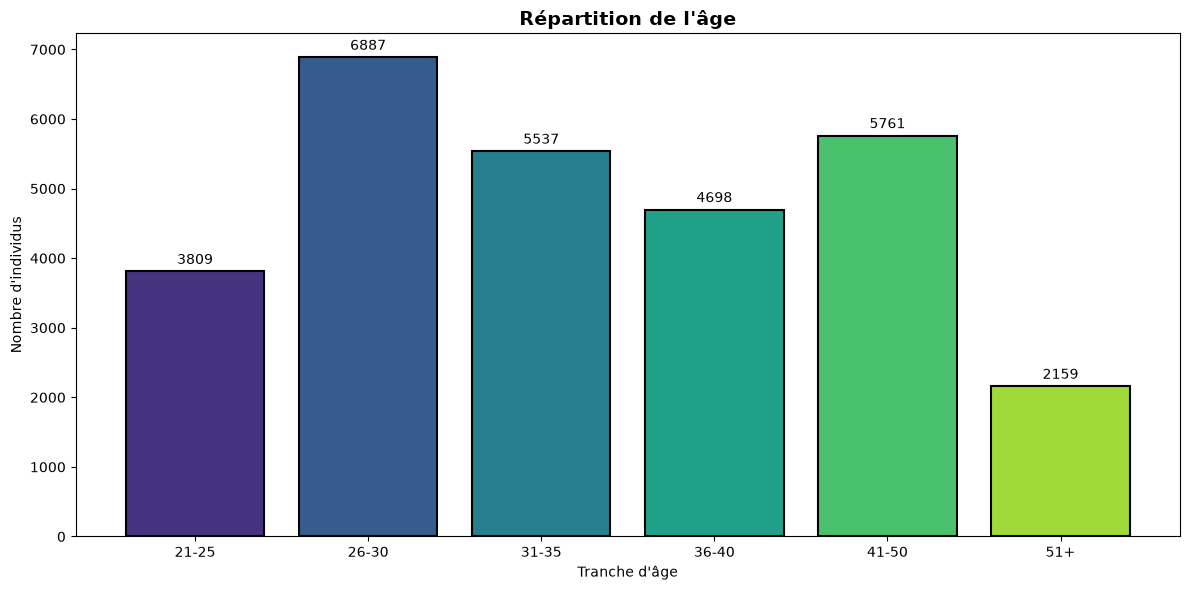

In [131]:
# 1. On compte les effectifs par bucket
counts = df['AGE_BUCKET'].value_counts().sort_index()

# On s'assure que l'ordre est respecté (du plus jeune au plus vieux)
# value_counts trie par défaut par fréquence, pas par ordre chronologique
order = ['21-25', '26-30', '31-35', '36-40', '41-50', '51+']
counts = counts.reindex(order)

# 2. On prépare les couleurs pour avoir un dégradé cohérent
# On récupère la palette 'viridis' de Seaborn/Matplotlib
palette = sns.color_palette('viridis', len(counts))

# 3. Création du graphique avec plt.bar (plus de contrôle que countplot)
fig, ax = plt.subplots(figsize=(12, 6))

# width=0.8 : Donne des barres larges mais qui laissent un petit interstice propre
# align='center' : Centre la barre exactement sur le label X
bars = ax.bar(
    counts.index, 
    counts.values, 
    width=0.8, 
    color=palette, 
    edgecolor='black', 
    linewidth=1.5
)

# 4. Mise en forme pour qu'il ressemble à un histogramme propre
ax.set_title('Répartition de l\'âge', fontweight='bold', fontsize=14)
ax.set_xlabel('Tranche d\'âge')
ax.set_ylabel('Nombre d\'individus')

# On ajoute les valeurs au dessus des barres pour la lisibilité
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points de décalage vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

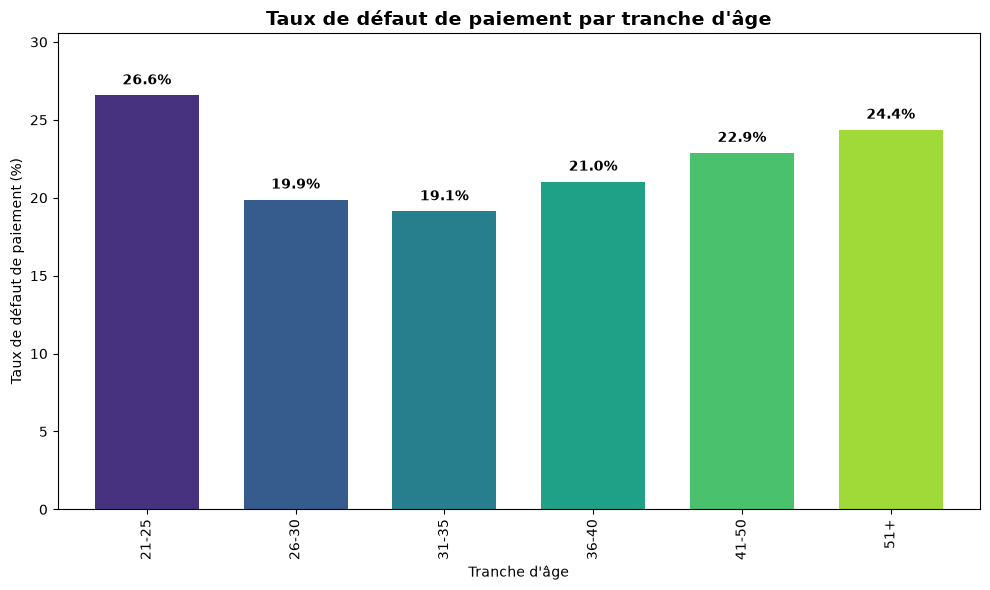

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul du taux de dpnm=1 par bucket
rates_by_age = df.groupby('AGE_BUCKET', observed=True)['dpnm'].mean().reindex(age_labels) * 100

# --- VISUALISATION SANS HEUR DE SEABORN (Plus propre) ---

# On utilise la palette viridis de seaborn juste pour récupérer les couleurs
colors = sns.color_palette('viridis', len(rates_by_age))

fig, ax = plt.subplots(figsize=(10, 6))

# On trace directement avec Pandas/Matplotlib sur l'axe ax
bars = rates_by_age.plot(
    kind='bar', 
    color=colors,       # Applique les couleurs du dégradé
    width=0.7,          # Largeur des barres
    legend=False,       # Pas de légende car x et data sont liés
    ax=ax               # Dessine sur notre axe
)

# Ajout des valeurs au dessus des barres
for bar in bars.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Taux de défaut de paiement par tranche d\'âge', fontweight='bold', fontsize=14)
ax.set_xlabel('Tranche d\'âge')
ax.set_ylabel('Taux de défaut de paiement (%)')
ax.set_ylim(0, max(rates_by_age.values) * 1.15)

plt.tight_layout()
plt.show()

**Interprétation**  
Taux de défaut plus élevé chez les jeunes de 25 ans et moins.  
Le défaut monte légèrement avec l'âge à partir de 36 ans.  
On voit ici une corrélation entre les tranches d'âge et le dpnm qui ne ressort pas si on regarde uniquement la valeur âge de manière linéaire

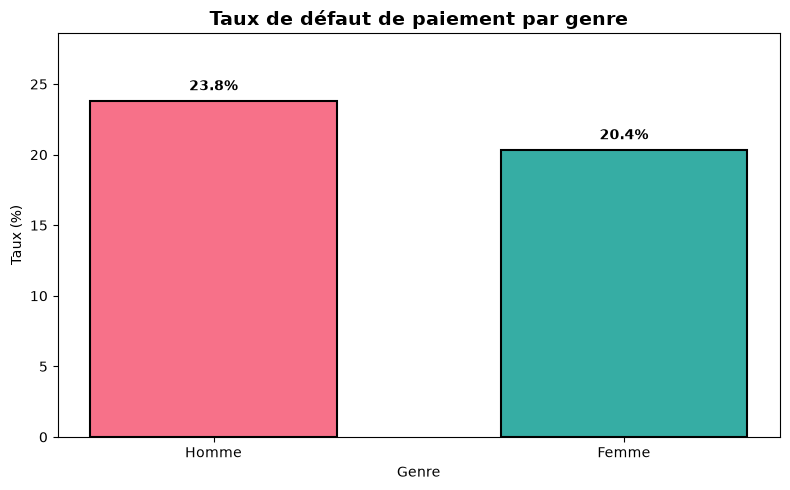

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcul du taux de dpnm par SEX en pourcentage directement
sex_rates_pct = (df.groupby('SEX', observed=True)['dpnm'].mean() * 100).round(2)

# 2. Définition des labels exacts
labels_map = {1: 'Homme', 2: 'Femme'}
display_labels = [labels_map.get(code, code) for code in sex_rates_pct.index]

# 3. Visualisation en barres
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    display_labels,
    sex_rates_pct.values,  # Utilisation directe des pourcentages
    width=0.6,
    color=sns.color_palette("husl", 2),
    edgecolor='black',
    linewidth=1.5
)

# Ajout des étiquettes au-dessus des barres
for bar in bars:
    height = bar.get_height()
    # Un décalage de +0.5 est maintenant proportionnel sur une échelle 0-100%
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Taux de défaut de paiement par genre', fontweight='bold', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Taux (%)')
ax.set_ylim(0, max(sex_rates_pct.values) * 1.2)  # Ajustement de la limite supérieure

plt.tight_layout()
plt.show()

**Interprétation**
Là où la heatmap ne détectait aucune corrélation, on voit sur les hommes ont un taux de défaut supérieur aux femmes de 3 points.

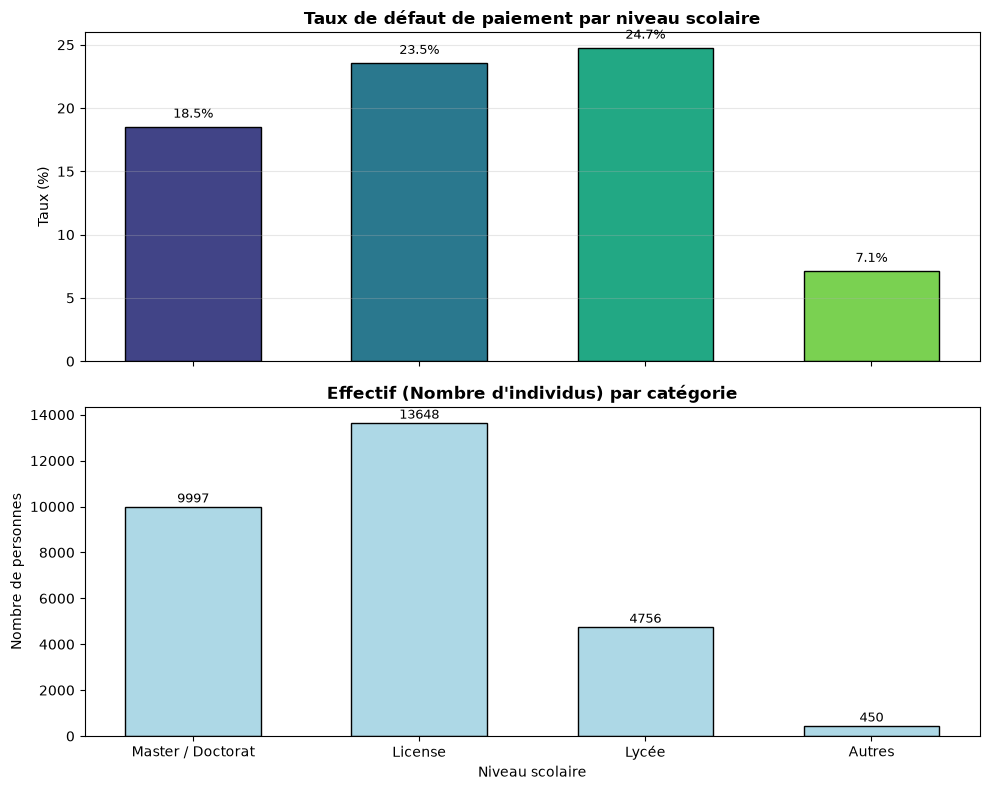


Tableau des taux de défaut de paiement par niveau scolaire :


,Code,Libellé,Taux dpnm=1 (%),Effectif (N)
0,1,Master / Doctorat,18.51,9997
1,2,License,23.54,13648
2,3,Lycée,24.75,4756
3,4,Autres,7.11,450


In [134]:
# 1. Définition des ordres et labels
education_map = {
    1: 'Master / Doctorat', 
    2: 'License', 
    3: 'Lycée', 
    4: 'Autres'
}
education_order_codes = [1, 2, 3, 4] 

# 2. Calcul du taux de dpnm
rates_by_edu = df.groupby('EDUCATION', observed=True)['dpnm'].mean() * 100

# Filtrage et tri selon l'ordre attendu
valid_codes = [c for c in education_order_codes if c in rates_by_edu.index]
rates_sorted = rates_by_edu.reindex(valid_codes)
labels = [education_map.get(code, f'Niveau {code}') for code in valid_codes]

# 3. Calcul des effectifs (pour contrôle de pertinence)
counts_by_edu = df.groupby('EDUCATION', observed=True).size().reindex(valid_codes)
count_values = counts_by_edu.values.astype(int)

# --- VISUALISATION ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Graphique des Taux (Haut)
palette_rates = sns.color_palette("viridis", len(valid_codes))
bars1 = ax1.bar(labels, rates_sorted.values, width=0.6, color=palette_rates, edgecolor='black', linewidth=1)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax1.set_title('Taux de défaut de paiement par niveau scolaire', fontweight='bold')
ax1.set_ylabel('Taux (%)')
ax1.grid(axis='y', alpha=0.3)

# Graphique des Effectifs (Bas) - Pour vérifier la robustesse statistique
bars2 = ax2.bar(labels, count_values, width=0.6, color='lightblue', edgecolor='black', linewidth=1)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 50, str(height), ha='center', va='bottom', fontsize=9)

ax2.set_title('Effectif (Nombre d\'individus) par catégorie', fontweight='bold')
ax2.set_xlabel('Niveau scolaire')
ax2.set_ylabel('Nombre de personnes')

plt.tight_layout()
plt.show()

# --- TABLEAU RÉCAPITULATIF ---
print("\nTableau des taux de défaut de paiement par niveau scolaire :")
pd.DataFrame({
    'Code': valid_codes,
    'Libellé': labels,
    'Taux dpnm=1 (%)': rates_sorted.values.round(2),
    'Effectif (N)': count_values
})

**Interprétation**  
Le taux de défaut augmente à mesure que le niveau scolaire diminue.  
La catégorie 'autres' a un taux de défaut très faible mais ne représente que 455 individus qui sont l'agglomérat de toutes les valeurs non répertoriées initialement et de la valeur 'autres'

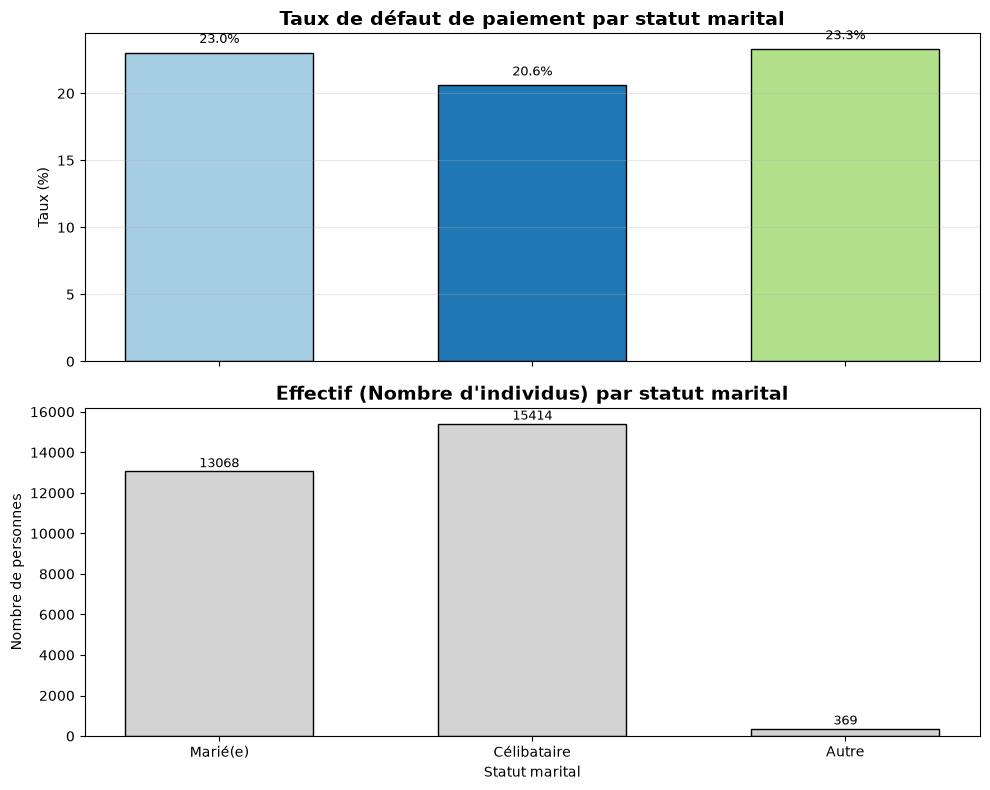


Tableau des taux de dpnm par statut marital :


,Code,Libellé,Taux dpnm=1 (%),Effectif (N)
MARRIAGE,,,,
1,1,Marié(e),23.03,13068
2,2,Célibataire,20.60,15414
3,3,Autre,23.31,369


In [135]:
# 1. Définition du mapping pour les labels lisibles
# Attention : Vérifie que tes codes (1, 2, 3) correspondent bien à ces libellés
marriage_map = {
    1: 'Marié(e)', 
    2: 'Célibataire', 
    3: 'Autre' 
}

# Ordre logique (peu importe l'ordre pour le groupby, mais utile si on veut forcer un tri visuel)
marriage_order = [1, 2, 3]

# 2. Calcul du taux de dpnm et des effectifs
rates_by_marriage = df.groupby('MARRIAGE', observed=True)['dpnm'].mean() * 100
counts_by_marriage = df.groupby('MARRIAGE', observed=True).size()

# On filtre pour ne garder que les codes qu'on veut afficher (s'il manque une catégorie dans le data)
valid_codes = [c for c in marriage_order if c in rates_by_marriage.index]

rates_sorted = rates_by_marriage.reindex(valid_codes)
count_values = counts_by_marriage.reindex(valid_codes).astype(int)

# Labels lisibles
labels = [marriage_map.get(code, f'Code {code}') for code in valid_codes]

# --- VISUALISATION COMBINÉE (Taux + Effectif) ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Graphique des Taux (Haut)
palette = sns.color_palette("Paired", len(valid_codes)) # Palette distincte pour catégories nominales
bars1 = ax1.bar(labels, rates_sorted.values, width=0.6, color=palette, edgecolor='black', linewidth=1)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax1.set_title('Taux de défaut de paiement par statut marital', fontweight='bold', fontsize=14)
ax1.set_ylabel('Taux (%)')
ax1.grid(axis='y', alpha=0.3)

# Graphique des Effectifs (Bas) - Contrôle de pertinence
bars2 = ax2.bar(labels, count_values, width=0.6, color='lightgrey', edgecolor='black', linewidth=1)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 50, str(height), ha='center', va='bottom', fontsize=9)

ax2.set_title('Effectif (Nombre d\'individus) par statut marital', fontweight='bold', fontsize=14)
ax2.set_xlabel('Statut marital')
ax2.set_ylabel('Nombre de personnes')

plt.tight_layout()
plt.show()

# --- TABLEAU RÉCAPITULATIF ---
print("\nTableau des taux de dpnm par statut marital :")
pd.DataFrame({
    'Code': valid_codes,
    'Libellé': labels,
    'Taux dpnm=1 (%)': rates_sorted.values.round(2),
    'Effectif (N)': count_values
})

**Interprétation**  
Les célibataires ont un défaut de paiement plus faible de l'ordre de 2.5 points.  
La catégorie 'autres' ne représente que 369 individus et est difficilement exploitables

### Interprétation des données démographiques
Au premier abord, les données personnelles semblaient dénués d'intérets mais en regardant de plus près, on constate des tendances :
- Les profils jeunes, mariés, avec un niveau scolaire plus faible ont un taux de défaut sensiblement supérieur au reste de la population  
Ces données seront une mine d'or pour les modèles d'apprentissage automatique.  

In [136]:
# Filtrage des données selon les critères : le profil qui semble présenter le plus de risque selon les 4 études précédentes
filtered_df = df[
    (df['SEX'] == 1) &
    (df['AGE'] <= 25) &
    ((df['EDUCATION'] == 2) | (df['EDUCATION'] == 3)) &
    (df['MARRIAGE'] == 1)
]

# Calcul du taux de défaut moyen
mean_dpnm = filtered_df['dpnm'].mean()

# Affichage du résultat
print(f"Taux de défaut de paiement moyen pour le groupe filtré : {mean_dpnm:.2%}")

# Affichage du nombre d'individus dans le groupe
count = len(filtered_df)
print(f"Nombre d'individus dans le groupe : {count}")

Taux de défaut de paiement moyen pour le groupe filtré : 35.85%
Nombre d'individus dans le groupe : 53


Quand on cumule les 4 "facteurs de risques", le taux de défaut s'envole mais le nombre d'individus n'est pas représentatif d'une tendance globale de fond.

In [137]:
# Filtrage des données selon les critères : le profil qui semble présenter le plus de risque selon les 4 études précédentes
filtered_df = df[
    (df['AGE'] <= 25) &
    ((df['EDUCATION'] == 2) | (df['EDUCATION'] == 3)) &
    (df['MARRIAGE'] == 1)
]

# Calcul du taux de défaut moyen
mean_dpnm = filtered_df['dpnm'].mean()

# Affichage du résultat
print(f"Taux de défaut de paiement moyen pour le groupe filtré : {mean_dpnm:.2%}")

# Affichage du nombre d'individus dans le groupe
count = len(filtered_df)
print(f"Nombre d'individus dans le groupe : {count}")

Taux de défaut de paiement moyen pour le groupe filtré : 31.61%
Nombre d'individus dans le groupe : 386


In [138]:
# Filtrage des données selon les critères : le profil qui semble présenter le plus de risque selon les 4 études précédentes
filtered_df = df[

    (df['AGE'] <= 25) &
    ((df['EDUCATION'] == 2) | (df['EDUCATION'] == 3)) 

]

# Calcul du taux de défaut moyen
mean_dpnm = filtered_df['dpnm'].mean()

# Affichage du résultat
print(f"Taux de défaut de paiement moyen pour le groupe filtré : {mean_dpnm:.2%}")

# Affichage du nombre d'individus dans le groupe
count = len(filtered_df)
print(f"Nombre d'individus dans le groupe : {count}")

Taux de défaut de paiement moyen pour le groupe filtré : 28.30%
Nombre d'individus dans le groupe : 2650


In [139]:
# Filtrage des données selon les nouveaux critères
filtered_df_2 = df[
    (df['SEX'] == 2) &
    (df['AGE'] > 25) &
    (df['MARRIAGE'] == 2) &
    (df['EDUCATION'] == 1)
]

# Calcul du taux de défaut moyen
mean_dpnm_2 = filtered_df_2['dpnm'].mean()

# Affichage du résultat
print(f"Taux de défaut de paiement moyen pour le groupe 2 : {mean_dpnm_2:.2%}")

# Affichage du nombre d'individus dans le groupe
count_2 = len(filtered_df_2)
print(f"Nombre d'individus dans le groupe 2 : {count_2}")

Taux de défaut de paiement moyen pour le groupe 2 : 16.06%
Nombre d'individus dans le groupe 2 : 3189


## Analyse du comportement bancaire

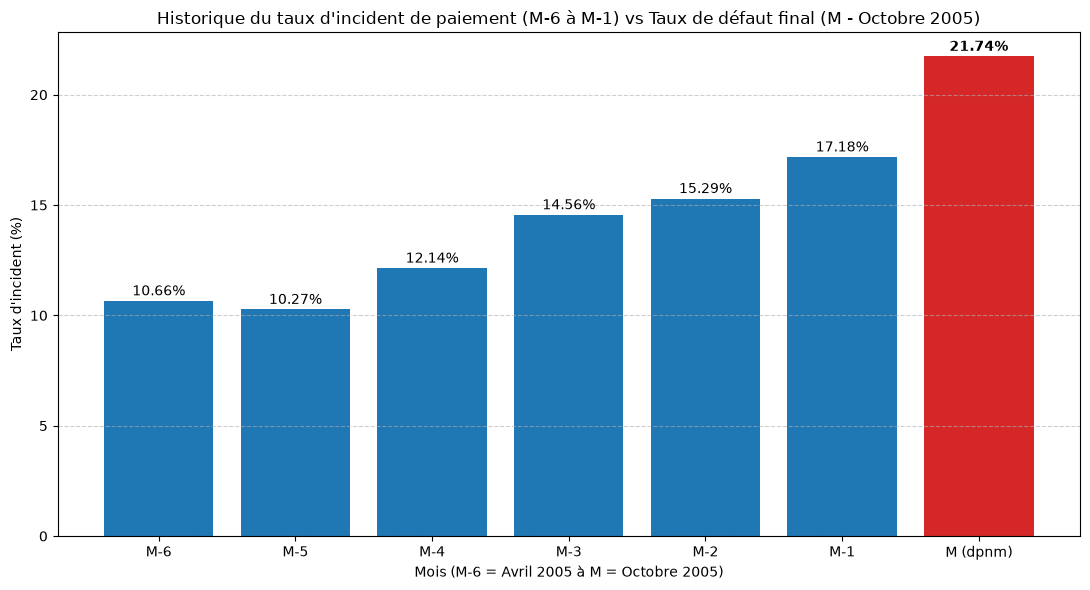

Résumé des taux (ordre chronologique + cible M) :
       Mois   Taux (%)
0       M-6  10.658209
1       M-5  10.270008
2       M-4  12.141694
3       M-3  14.557554
4       M-2  15.292364
5       M-1  17.177914
6  M (dpnm)  21.739281


In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes dans l'ordre chronologique (M-6 à M-1) + cible M
colonnes_pay = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_1']
mois_labels = ['M-6', 'M-5', 'M-4', 'M-3', 'M-2', 'M-1', 'M (dpnm)']

total_clients = len(df)
taux_values = []

# Calcul du taux de retard (PAY_n > 0) pour chaque mois d'observation
for col in colonnes_pay:
    nb_occurrences = (df[col] > 0).sum()
    taux_pct = (nb_occurrences / total_clients) * 100
    taux_values.append(taux_pct)

# Ajout du taux de défaut réel pour le mois M (dpnm = 1)
taux_dpnm = (df['dpnm'] == 1).sum() / total_clients * 100
taux_values.append(taux_dpnm)

# Palette de couleurs : bleu pour l'historique M-6 à M-1, rouge pour la cible M
couleurs = ['#1f77b4'] * 6 + ['#d62728']

# Créer le graphique
plt.figure(figsize=(11, 6))
bars = plt.bar(mois_labels, taux_values, color=couleurs)

# Ajouter les valeurs sur les barres
for i, taux_val in enumerate(taux_values):
    plt.text(i, taux_val + 0.1, f'{taux_val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold' if i == 6 else 'normal')

plt.title('Historique du taux d\'incident de paiement (M-6 à M-1) vs Taux de défaut final (M - Octobre 2005)')
plt.xlabel('Mois (M-6 = Avril 2005 à M = Octobre 2005)')
plt.ylabel('Taux d\'incident (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des taux (ordre chronologique + cible M) :")
resultats = pd.DataFrame({
    'Mois': mois_labels,
    'Taux (%)': taux_values
})
print(resultats)

**Interprétation**  
Client en incidents de paiement (meme temporaire en septembre cofidication 1)  
hausse continue du pourcentage de clients ayant au moins un retard avec affichage du défaut de paiement futur qui suit la même tendance

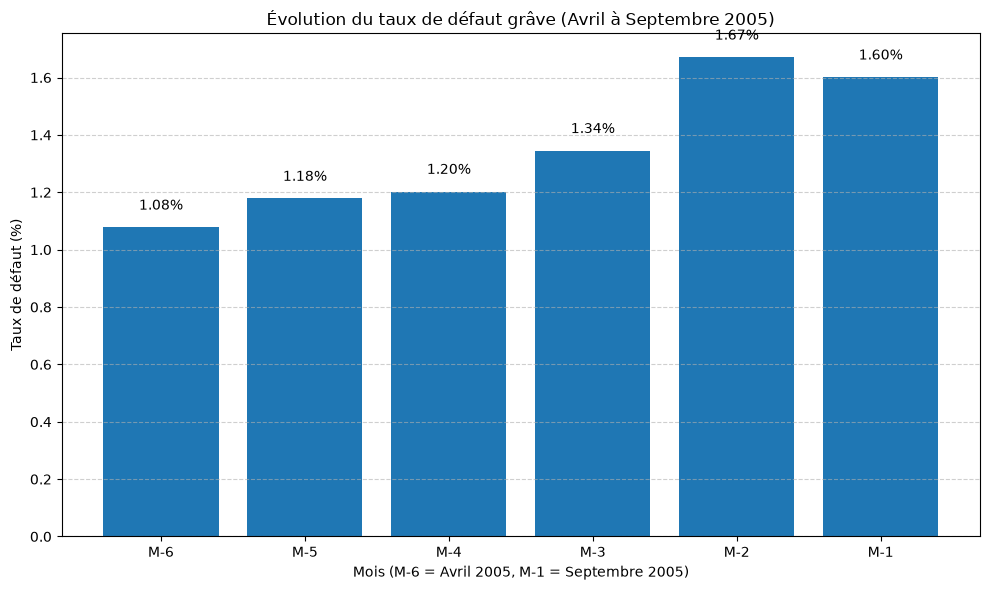

Résumé des taux de défaut (ordre chronologique) :
  Mois  Taux de défaut (%)
0  M-6            1.077952
1  M-5            1.178469
2  M-4            1.202731
3  M-3            1.344841
4  M-2            1.670653
5  M-1            1.601331


In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes dans l'ordre chronologique (M-6 à M-1)
colonnes_pay = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_1']
mois_labels = ['M-6', 'M-5', 'M-4', 'M-3', 'M-2', 'M-1']

total_clients = len(df)
taux_values = []

# Calcul du taux de défaut (PAY_n > 2) pour chaque mois
for col in colonnes_pay:
    nb_occurrences = (df[col] > 2).sum()
    taux_pct = (nb_occurrences / total_clients) * 100  # Correction : * 100 pour le pourcentage
    taux_values.append(taux_pct)

# Créer le graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(mois_labels, taux_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, taux_val in enumerate(taux_values):
    plt.text(i, taux_val + 0.05, f'{taux_val:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title('Évolution du taux de défaut grâve (Avril à Septembre 2005)')
plt.xlabel('Mois (M-6 = Avril 2005, M-1 = Septembre 2005)')
plt.ylabel('Taux de défaut (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des taux de défaut (ordre chronologique) :")
resultats = pd.DataFrame({
    'Mois': mois_labels,
    'Taux de défaut (%)': taux_values
})
print(resultats)

**Interprétation**  
Le nombre de clients en incidents avérés (> 2 mois de retard) augmente de plus en plus  
Non seulement la proportion de clients qui est en défaut augmente mais en plus la gravaté du retard progresse encore davantage

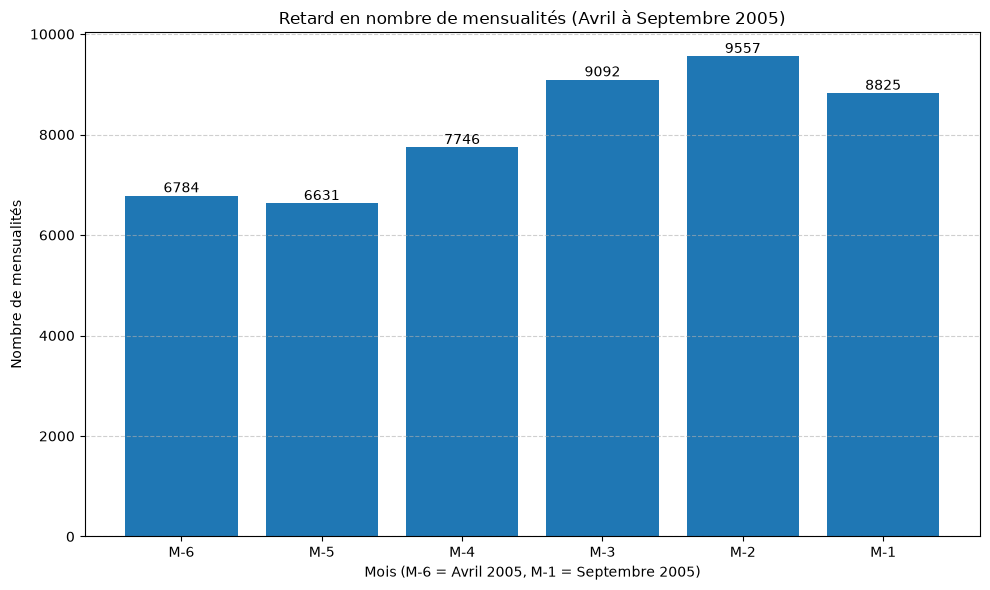

Résumé des sommes de retards (ordre chronologique) :
  Mois  Somme des retards
0  M-6               6784
1  M-5               6631
2  M-4               7746
3  M-3               9092
4  M-2               9557
5  M-1               8825


In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identifier les colonnes dans l'ordre chronologique (M-6 à M-1)
colonnes_pay = ['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_1']
mois_labels = ['M-6', 'M-5', 'M-4', 'M-3', 'M-2', 'M-1']

# Calculer la somme des valeurs positives pour chaque mois
sommes_cumulees = {}
for col in colonnes_pay:
    sommes_cumulees[col] = df[col][df[col] > 0].sum()

somme_values = list(sommes_cumulees.values())

# Créer le graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(mois_labels, somme_values, color='#1f77b4')

# Ajouter les valeurs sur les barres
for i, somme in enumerate(somme_values):
    plt.text(i, somme + 0.5, str(somme), ha='center', va='bottom', fontsize=10)

plt.title('Retard en nombre de mensualités (Avril à Septembre 2005)')
plt.xlabel('Mois (M-6 = Avril 2005, M-1 = Septembre 2005)')
plt.ylabel('Nombre de mensualités')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Afficher les résultats sous forme de tableau
print("Résumé des sommes de retards (ordre chronologique) :")
resultats = pd.DataFrame({
    'Mois': mois_labels,
    'Somme des retards': somme_values
})
print(resultats)

### Analyse des plafonds de crédits, de leur utilisation et du défaut lié

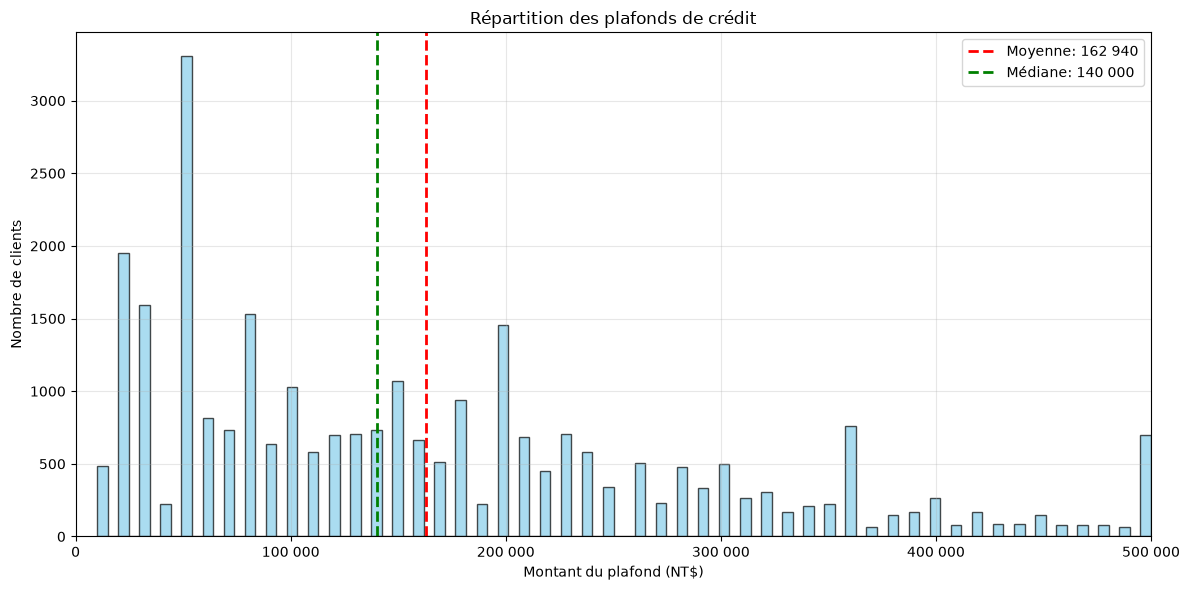

In [143]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Création de l'histogramme avec bins
plt.figure(figsize=(12, 6))
plt.hist(df['LIMIT_BAL'].dropna(), bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Montant du plafond (NT$)')
plt.ylabel('Nombre de clients')
plt.title('Répartition des plafonds de crédit')
plt.grid(True, alpha=0.3)

# Ajouter quelques statistiques sur le graphique
mean_val = df['LIMIT_BAL'].mean()
median_val = df['LIMIT_BAL'].median()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
           label=f'Moyenne: {int(mean_val):,}'.replace(',', ' '))
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, 
           label=f'Médiane: {int(median_val):,}'.replace(',', ' '))

# Forcer l'affichage des nombres complets sans notation scientifique
plt.ticklabel_format(style='plain', axis='x')

# Remplacer les séparateurs de milliers par des espaces
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

# Forcer l'axe des abscisses à commencer à 0 en forçant les limites
x_min = 0
x_max = df['LIMIT_BAL'].max()
ax.set_xlim(x_min, x_max)

plt.legend()
plt.tight_layout()
plt.show()


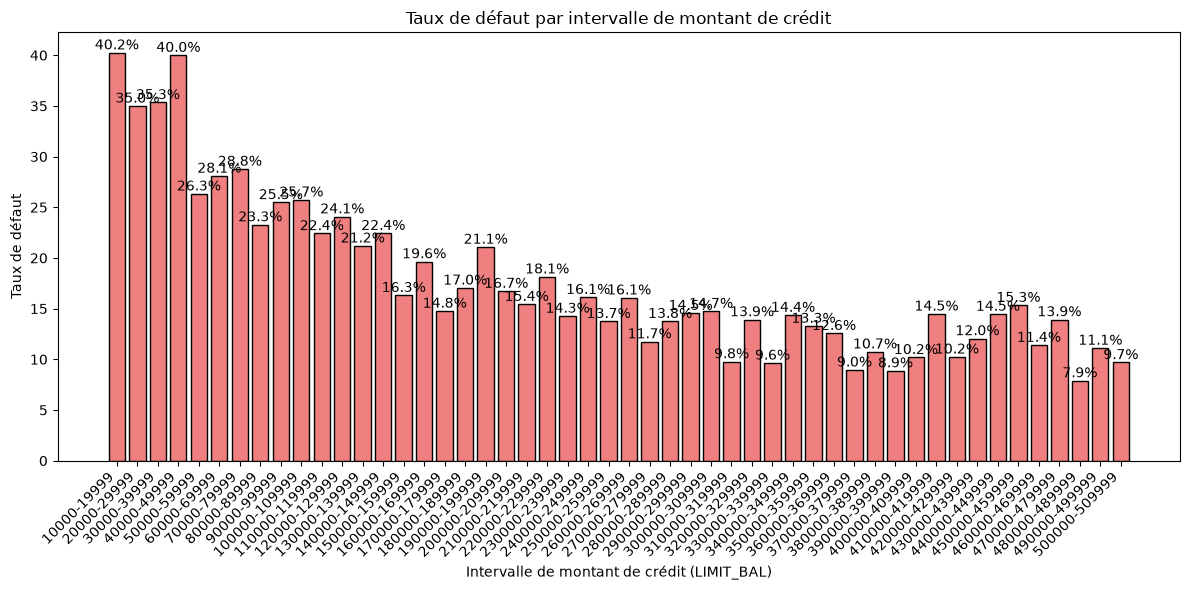

In [144]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Supposons que vous ayez une colonne 'default' où 1 = défaut, 0 = non défaut
# Si vous n'avez pas cette colonne, nous devons la créer ou utiliser une autre méthode

# Création du taux de défaut par intervalle de LIMIT_BAL
# On divise en intervalles de 10 000 comme demandé
bin_size = 10000
num_bins = int(1000000 / bin_size)

# Créer les intervalles
bins = np.arange(0, 1000001, bin_size)
labels = [f'{i}-{i+bin_size-1}' for i in bins[:-1]]

# Assigner chaque client à un intervalle
df['LIMIT_BAL_interval'] = pd.cut(df['LIMIT_BAL'], 
                                          bins=bins, labels=labels, right=False)

# Calculer le taux de défaut pour chaque intervalle
if 'dpnm' in df.columns:
    # Si vous avez une colonne 'default'
    default_rates = df.groupby('LIMIT_BAL_interval')['dpnm'].mean()
    
    # Créer le graphique
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(default_rates)), default_rates.values*100, color='lightcoral', edgecolor='black')
    
    plt.xlabel('Intervalle de montant de crédit (LIMIT_BAL)')
    plt.ylabel('Taux de défaut')
    plt.title('Taux de défaut par intervalle de montant de crédit')
    plt.xticks(range(len(default_rates)), default_rates.index, rotation=45, ha='right')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, rate) in enumerate(zip(bars, default_rates.values)):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{rate:.1%}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Aucune colonne 'default' trouvée dans le DataFrame")
    print("Colonnes disponibles :", df.columns.tolist())

On constate un taux de défaut moyen qui a tendance à baisser au fur et à mesure que le plafond augmente

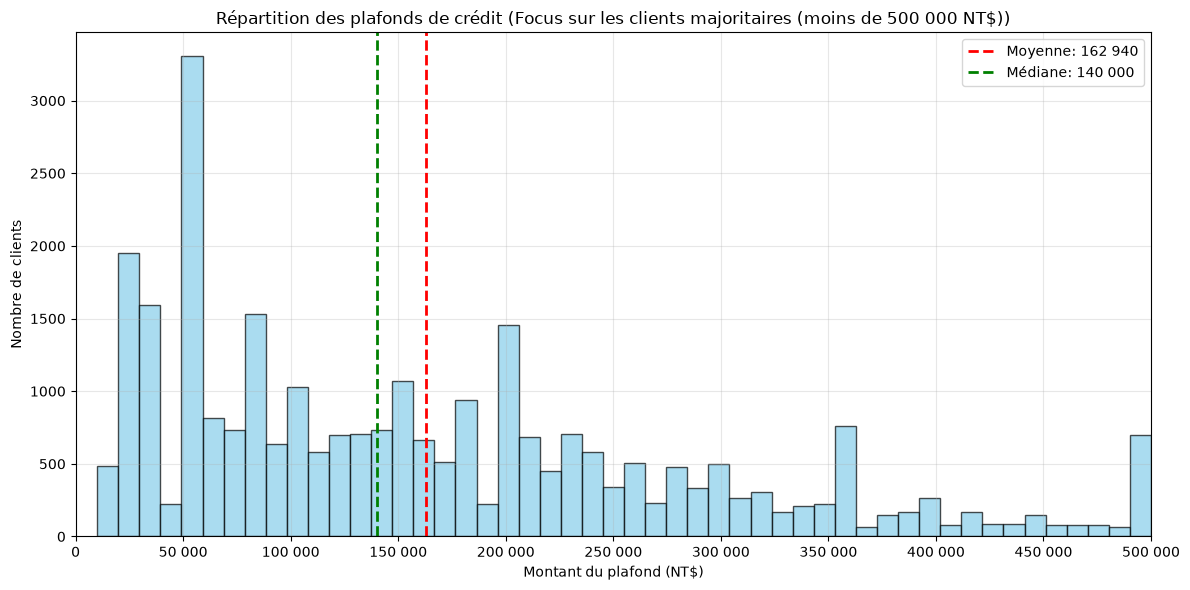

In [145]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filtrer les données pour ne garder que les valeurs <= 500000
df_filtered = df[df['LIMIT_BAL'] <= 500000]

# Création de l'histogramme avec bins
plt.figure(figsize=(12, 6))
plt.hist(df_filtered['LIMIT_BAL'].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Montant du plafond (NT$)')
plt.ylabel('Nombre de clients')
plt.title('Répartition des plafonds de crédit (Focus sur les clients majoritaires (moins de 500 000 NT$))')
plt.grid(True, alpha=0.3)

# Ajouter quelques statistiques sur le graphique
mean_val = df_filtered['LIMIT_BAL'].mean()
median_val = df_filtered['LIMIT_BAL'].median()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
           label=f'Moyenne: {int(mean_val):,}'.replace(',', ' '))
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, 
           label=f'Médiane: {int(median_val):,}'.replace(',', ' '))

# Forcer l'affichage des nombres complets sans notation scientifique
plt.ticklabel_format(style='plain', axis='x')

# Remplacer les séparateurs de milliers par des espaces
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

# Configurer les graduations de l'axe X pour qu'elles soient toutes les 100 000
ax.set_xticks(range(0, 500001, 50000))

# Forcer l'axe des abscisses à commencer à 0
x_min = 0
x_max = 500000
ax.set_xlim(x_min, x_max)

plt.legend()
plt.tight_layout()
plt.show()

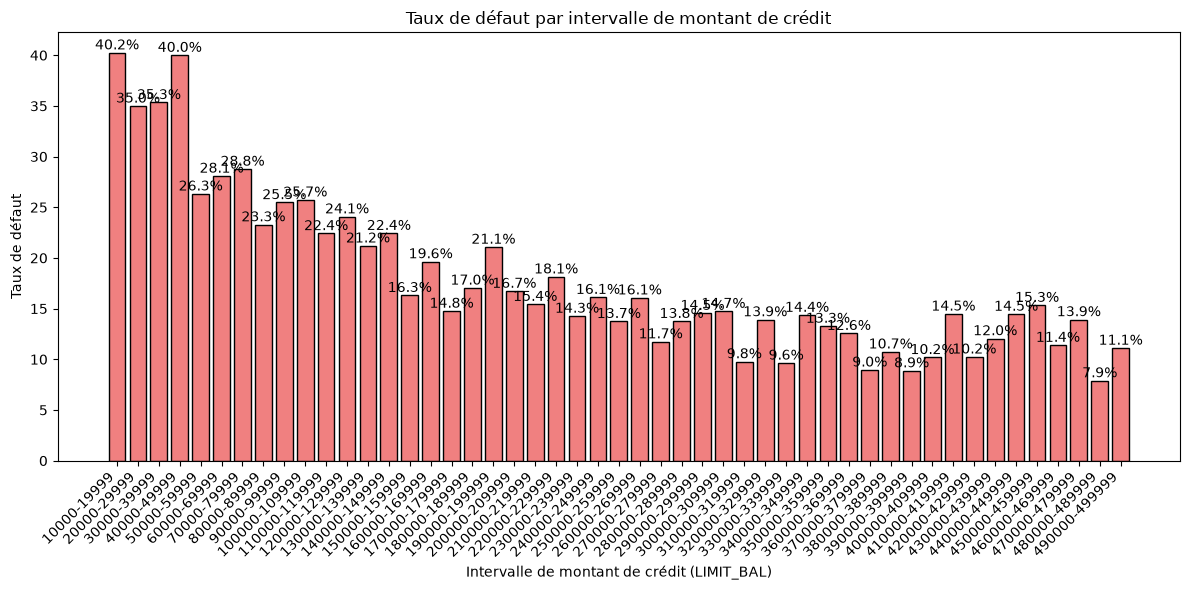

In [146]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Supposons que vous ayez une colonne 'default' où 1 = défaut, 0 = non défaut
# Si vous n'avez pas cette colonne, nous devons la créer ou utiliser une autre méthode

# Filtrer les données pour ne garder que les valeurs <= 500000
df_filtered = df[df['LIMIT_BAL'] <= 500000]

# Création du taux de défaut par intervalle de LIMIT_BAL
# On divise en intervalles de 10 000 comme demandé
bin_size = 10000
num_bins = int(500000 / bin_size)

# Créer les intervalles
bins = np.arange(0, 500001, bin_size)
labels = [f'{i}-{i+bin_size-1}' for i in bins[:-1]]

# Assigner chaque client à un intervalle
df_filtered['LIMIT_BAL_interval'] = pd.cut(df_filtered['LIMIT_BAL'], 
                                          bins=bins, labels=labels, right=False)

# Calculer le taux de défaut pour chaque intervalle
if 'dpnm' in df_filtered.columns:
    # Si vous avez une colonne 'default'
    default_rates = df_filtered.groupby('LIMIT_BAL_interval')['dpnm'].mean()
    
    # Créer le graphique
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(default_rates)), default_rates.values*100, color='lightcoral', edgecolor='black')
    
    plt.xlabel('Intervalle de montant de crédit (LIMIT_BAL)')
    plt.ylabel('Taux de défaut')
    plt.title('Taux de défaut par intervalle de montant de crédit')
    plt.xticks(range(len(default_rates)), default_rates.index, rotation=45, ha='right')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, rate) in enumerate(zip(bars, default_rates.values)):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{rate:.1%}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Aucune colonne 'default' trouvée dans le DataFrame")
    print("Colonnes disponibles :", df_filtered.columns.tolist())

**Interprétation**  
Le taux augmente fortement sur les plus petits crédits.  

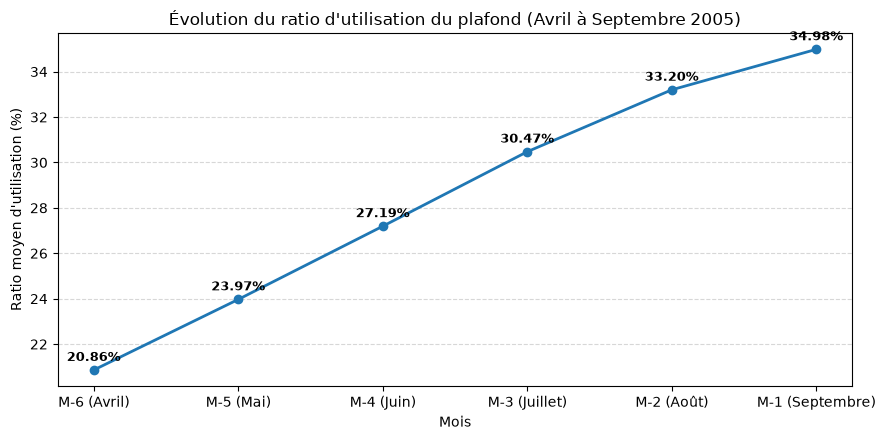

,Mois,Ratio moyen (%)
0,M-6 (Avril),20.859231
1,M-5 (Mai),23.968000
2,M-4 (Juin),27.192000
3,M-3 (Juillet),30.473000
4,M-2 (Août),33.200000
5,M-1 (Septembre),34.981500


In [147]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Alignement direct : du plus ancien (M-6 / ratio 6) au plus récent (M-1 / ratio 1)
mapping = [
    ('M-6 (Avril)', 'ratio_BILL_LIMIT6'),
    ('M-5 (Mai)', 'ratio_BILL_LIMIT5'),
    ('M-4 (Juin)', 'ratio_BILL_LIMIT4'),
    ('M-3 (Juillet)', 'ratio_BILL_LIMIT3'),
    ('M-2 (Août)', 'ratio_BILL_LIMIT2'),
    ('M-1 (Septembre)', 'ratio_BILL_LIMIT1')
]

labels = []
medianes = []

# 2. Calcul séquentiel
for label, col in mapping:
    if col in df.columns:
        labels.append(label)
        medianes.append(df[col].median())

# 3. Tracé Matplotlib natif (évite les bugs de typage Seaborn)
plt.figure(figsize=(9, 4.5))
plt.plot(labels, medianes, marker='o', color='#1f77b4', linewidth=2)

plt.title("Évolution du ratio d'utilisation du plafond (Avril à Septembre 2005)")
plt.xlabel("Mois")
plt.ylabel("Ratio moyen d'utilisation (%)")

for i, val in enumerate(medianes):
    plt.text(i, val + 0.4, f"{val:.2f}%", ha='center', fontsize=9, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
pd.DataFrame({'Mois': labels, 'Ratio moyen (%)': medianes})

**Interprétation**  
Hausse constante de l'utilisation de leur plafond par les client avec une hausse de 11 points en 6 mois  
Qui utilise le plus son plafond ?

In [148]:
ratio_plafond = ['LIMIT_BAL','ratio_BILL_LIMIT1', 'ratio_BILL_LIMIT2',
       'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4', 'ratio_BILL_LIMIT5',
       'ratio_BILL_LIMIT6']
df[ratio_plafond].describe()

,LIMIT_BAL,ratio_BILL_LIMIT1,ratio_BILL_LIMIT2,ratio_BILL_LIMIT3,ratio_BILL_LIMIT4,ratio_BILL_LIMIT5,ratio_BILL_LIMIT6
count,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000,28851.000000
mean,162940.268275,43.765052,42.483930,40.502543,37.201205,34.471693,32.993875
std,124911.013950,40.409015,39.784494,38.715731,36.558641,34.814705,34.463329
min,10000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,2.972867,2.514900,2.238985,2.057321,1.580238,1.153636
50%,140000.000000,34.981500,33.200000,30.473000,27.192000,23.968000,20.859231
75%,230000.000000,84.329333,82.122500,77.366500,68.427885,61.370000,59.383000
max,500000.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000


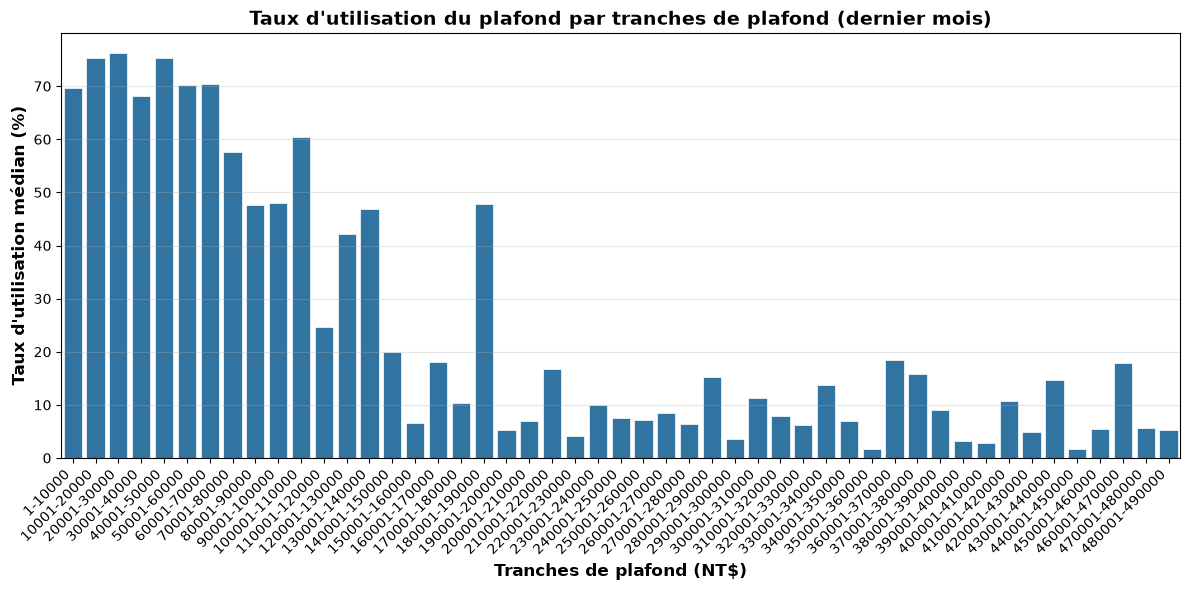

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filtrer les données pour les clients avec plafond <= 500000
df_filtered = df[df['LIMIT_BAL'] <= 500000]

# Vérifier si la colonne existe
if 'ratio_BILL_LIMIT1' in df_filtered.columns:
    # Création des tranches de plafond
    bin_size = 10000
    bins = np.arange(1, 500001, bin_size)
    labels = [f'{i}-{i+bin_size-1}' for i in bins[:-1]]
    
    # Assigner chaque client à une tranche
    df_filtered['LIMIT_BAL_bin'] = pd.cut(df_filtered['LIMIT_BAL'], 
                                         bins=bins, labels=labels, right=False)
    
    # Calculer le taux d'utilisation moyen par tranche
    usage_by_bin = df_filtered.groupby('LIMIT_BAL_bin')['ratio_BILL_LIMIT1'].median().reset_index()
    
    # Création du graphique avec seaborn
    plt.figure(figsize=(12, 6))
    
    # Utilisation de seaborn pour le graphique en barres
    ax = sns.barplot(data=usage_by_bin, x='LIMIT_BAL_bin', y='ratio_BILL_LIMIT1', 
                     linewidth=0.5, edgecolor='white')
    
    # Personnalisation du graphique
    plt.title('Taux d\'utilisation du plafond par tranches de plafond (dernier mois)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Tranches de plafond (NT$)', fontsize=12, fontweight='bold')
    plt.ylabel('Taux d\'utilisation médian (%)', fontsize=12, fontweight='bold')
    
    # Rotation des étiquettes
    plt.xticks(rotation=45, ha='right')
    
    # Ajout d'une grille
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    # Afficher le graphique
    plt.show()
    
else:
    print("La colonne 'ratio_BILL_LIMIT1' n'existe pas dans le DataFrame")
    print("Colonnes disponibles :", df_filtered.columns.tolist())

**Interprétation**  
Clairement, les petits plafonds sont de loin les plus utilisés

Nombre de clients avec une utilisation moyenne à 0% : 25
Nombre de clients avec une utilisation moyenne supérieure à 120% : 82


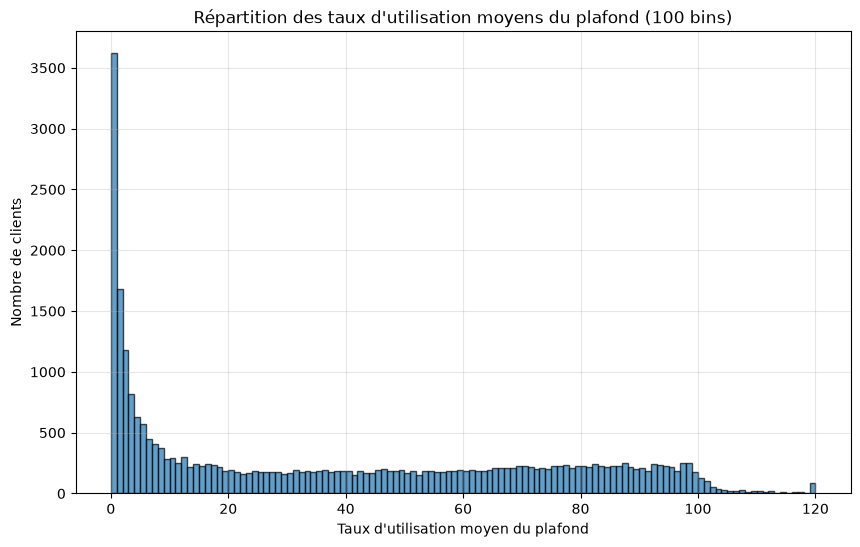

Statistiques descriptives :
count    28851.000000
mean        38.569716
std         34.776566
min          0.000000
25%          3.900222
50%         31.349839
75%         69.997595
max        200.000000
Name: mean_ratio, dtype: float64


In [150]:
# Répartition du taux d'utilisation médian du plafond sur les 6 derniers mois
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calcul de la moyenne des ratios d'utilisation pour chaque client sur les 6 mois
ratio_plafond = ['ratio_BILL_LIMIT1', 'ratio_BILL_LIMIT2', 
                 'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4', 
                 'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6']

# Calcul de la moyenne par client sur les 6 mois
df['mean_ratio'] = df[ratio_plafond].mean(axis=1)
print(f"Nombre de clients avec une utilisation moyenne à 0% : {df[df['mean_ratio']==0]['mean_ratio'].count()}")
print(f"Nombre de clients avec une utilisation moyenne supérieure à 120% : {df[df['mean_ratio']>120]['mean_ratio'].count()}")

# Création d'un histogramme avec 100 bins
plt.figure(figsize=(10, 6))
plt.hist(df['mean_ratio'].clip(upper=120), bins=120, edgecolor='black', alpha=0.7)
plt.xlabel('Taux d\'utilisation moyen du plafond')
plt.ylabel('Nombre de clients')
plt.title('Répartition des taux d\'utilisation moyens du plafond (100 bins)')
plt.grid(True, alpha=0.3)
plt.show()

# Affichage des statistiques descriptives
print("Statistiques descriptives :")
print(df['mean_ratio'].describe())

Nombre de clients avec une utilisation à 0% : 1649
Nombre de clients avec une utilisation supérieure à 120% : 333


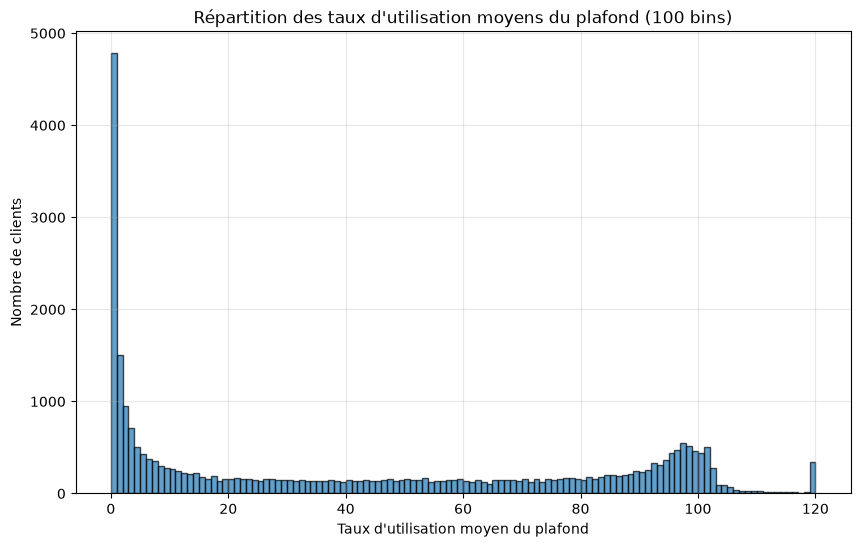

Statistiques descriptives :
count    28851.000000
mean        38.569716
std         34.776566
min          0.000000
25%          3.900222
50%         31.349839
75%         69.997595
max        200.000000
Name: mean_ratio, dtype: float64


In [151]:
# Répartition du taux d'utilisation médian du plafond sur le dernier mois
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print(f"Nombre de clients avec une utilisation à 0% : {df[df['ratio_BILL_LIMIT1']==0]['ratio_BILL_LIMIT1'].count()}")
print(f"Nombre de clients avec une utilisation supérieure à 120% : {df[df['ratio_BILL_LIMIT1']>120]['ratio_BILL_LIMIT1'].count()}")

# Création d'un histogramme avec 100 bins
plt.figure(figsize=(10, 6))
plt.hist(df['ratio_BILL_LIMIT1'].clip(upper=120), bins=120, edgecolor='black', alpha=0.7)
plt.xlabel('Taux d\'utilisation moyen du plafond')
plt.ylabel('Nombre de clients')
plt.title('Répartition des taux d\'utilisation moyens du plafond (100 bins)')
plt.grid(True, alpha=0.3)
plt.show()

# Affichage des statistiques descriptives
print("Statistiques descriptives :")
print(df['mean_ratio'].describe())

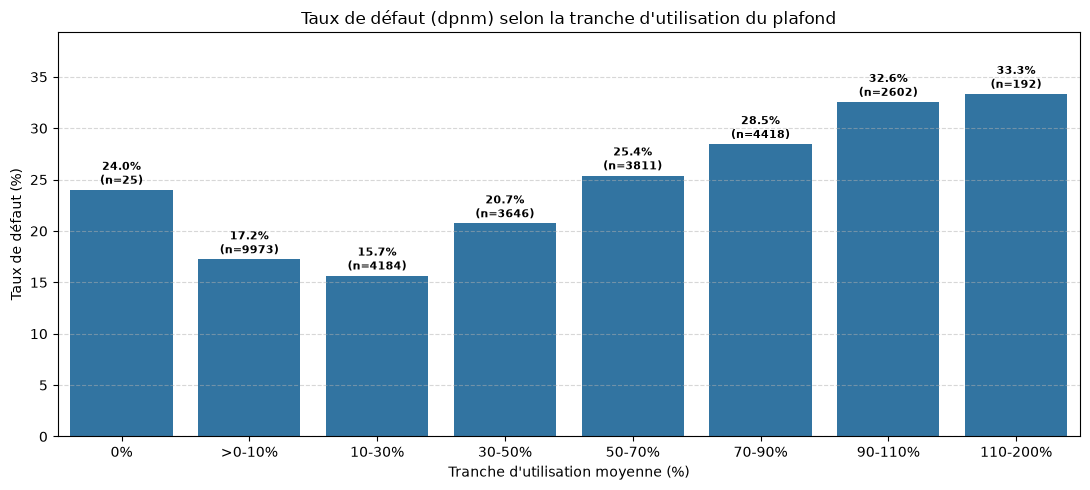

,ratio_mean_bin,nb_clients,taux_defaut
0,0%,25,24.000000
1,>0-10%,9973,17.236539
2,10-30%,4184,15.654876
3,30-50%,3646,20.735052
4,50-70%,3811,25.400157
5,70-90%,4418,28.451788
6,90-110%,2602,32.551883
7,110-200%,192,33.333333


In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ratio_cols = [f'ratio_BILL_LIMIT{i}' for i in range(1, 7)]

# 1. Calcul du ratio moyen et max par client
df['ratio_mean_client'] = df[ratio_cols].mean(axis=1)
df['ratio_max_client'] = df[ratio_cols].max(axis=1)


# 1. Redéfinition des tranches en isolant exactement la valeur 0 %
bins = [-0.01, 0.0, 10, 30, 50, 70, 90, 110, 200]
labels = ['0%', '>0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-110%', '110-200%']

df['ratio_mean_bin'] = pd.cut(df['ratio_mean_client'], bins=bins, labels=labels)

# 2. Agrégation : effectifs et taux de défaut moyen (dpnm)
stats_defaut = df.groupby('ratio_mean_bin', observed=False)['dpnm'].agg(
    nb_clients='count',
    taux_defaut=lambda x: x.mean() * 100
).reset_index()

# 3. Tracé du graphique avec le bin 0 % isolé
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=stats_defaut, x='ratio_mean_bin', y='taux_defaut', color='#1f77b4')

plt.title("Taux de défaut (dpnm) selon la tranche d'utilisation du plafond")
plt.xlabel("Tranche d'utilisation moyenne (%)")
plt.ylabel("Taux de défaut (%)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotation du taux de défaut et du nombre de clients par barre
for i, row in stats_defaut.iterrows():
    if not pd.isna(row['taux_defaut']):
        plt.text(
            i, 
            row['taux_defaut'] + 0.6, 
            f"{row['taux_defaut']:.1f}%\n(n={int(row['nb_clients'])})", 
            ha='center', 
            fontsize=8, 
            fontweight='bold'
        )

plt.ylim(0, max(stats_defaut['taux_defaut'].dropna(), default=30) + 6)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
stats_defaut

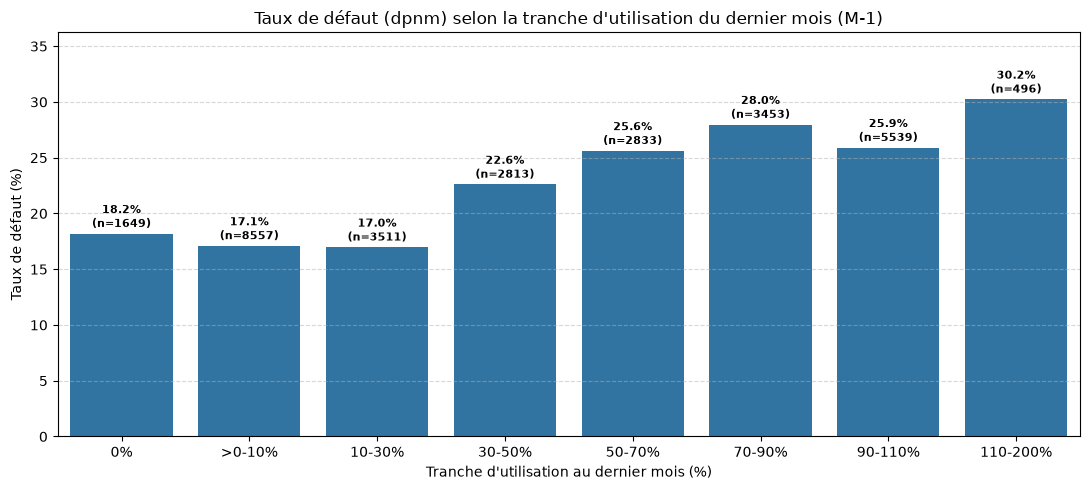

,ratio_m1_bin,nb_clients,taux_defaut
0,0%,1649,18.192844
1,>0-10%,8557,17.097113
2,10-30%,3511,16.975221
3,30-50%,2813,22.609314
4,50-70%,2833,25.626544
5,70-90%,3453,27.975673
6,90-110%,5539,25.907203
7,110-200%,496,30.241935


In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tranches d'utilisation uniquement sur le dernier mois (ratio_BILL_LIMIT1)
bins = [-0.01, 0.0, 10, 30, 50, 70, 90, 110, 200]
labels = ['0%', '>0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-110%', '110-200%']

df['ratio_m1_bin'] = pd.cut(df['ratio_BILL_LIMIT1'], bins=bins, labels=labels)

# 2. Agrégation : effectifs et taux de défaut (dpnm) sur M-1
stats_defaut_m1 = df.groupby('ratio_m1_bin', observed=False)['dpnm'].agg(
    nb_clients='count',
    taux_defaut=lambda x: x.mean() * 100
).reset_index()

# 3. Tracé du graphique
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=stats_defaut_m1, x='ratio_m1_bin', y='taux_defaut', color='#1f77b4')

plt.title("Taux de défaut (dpnm) selon la tranche d'utilisation du dernier mois (M-1)")
plt.xlabel("Tranche d'utilisation au dernier mois (%)")
plt.ylabel("Taux de défaut (%)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotation des barres
for i, row in stats_defaut_m1.iterrows():
    if not pd.isna(row['taux_defaut']):
        plt.text(
            i, 
            row['taux_defaut'] + 0.6, 
            f"{row['taux_defaut']:.1f}%\n(n={int(row['nb_clients'])})", 
            ha='center', 
            fontsize=8, 
            fontweight='bold'
        )

plt.ylim(0, max(stats_defaut_m1['taux_defaut'].dropna(), default=30) + 6)
plt.tight_layout()
plt.show()

# Tableau récapitulatif M-1
stats_defaut_m1

**Interprétation**  
On comprend la pollution du heatmap concernant l'utilisation du plafond, avec une utilisation nulle, on a un taux de défaut tres important (pour seulement 106 individus), probablement des comptes sortis du circuit gérés au contentieux, mais qui sont comptabilisés dans les stats de défaut, à voir si on peut les corriger, les nettoyer ou les étiqueter pour le ML
Une tendance nette pour le reste : plus le taux d'utilisation moyen augmente et plus le risque de défaut aurgmente.  
Tendance moins flagrante si on ne regarde que le dernier mois  
néanmoins une tendance de fond est similaire que précédemment, plus le client utilise son plafond, plus le risque de défaut augmente.  
A noter que les 1755 clients sans encours sont ici une anomalie, un modèle ne prédira pas un défaut sur un encours nul, ce sont probablement des clients sortis du circuit de gestion classique

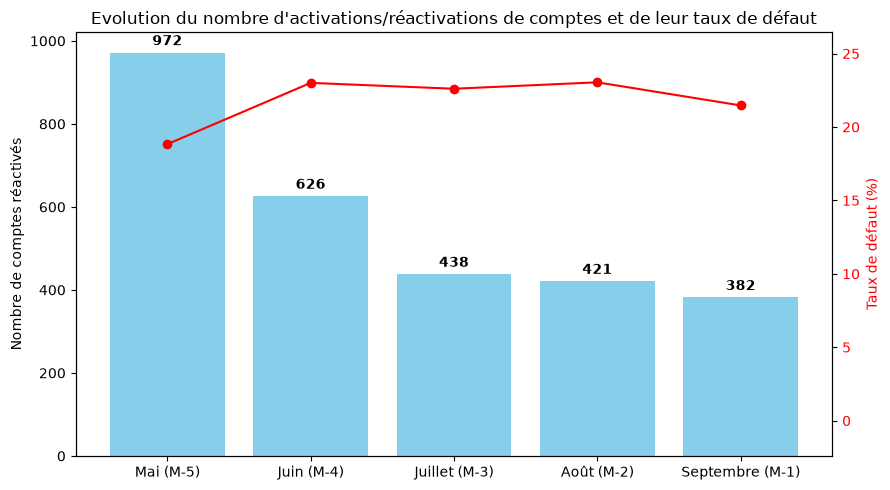

--- Comptage des sorties de sommeil ---
Mois de réactivation  Nombre de réactivations  Taux de défaut
           Mai (M-5)                      972       18.827160
          Juin (M-4)                      626       23.003195
       Juillet (M-3)                      438       22.602740
          Août (M-2)                      421       23.040380
     Septembre (M-1)                      382       21.465969


In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Définition des cycles chronologiques (de Mai M-4 à Septembre M)
cycles = [
    {'mois': 'Mai (M-5)', 'curr_bill': 'BILL_AMT5', 'dormant_cols': [6]},
    {'mois': 'Juin (M-4)', 'curr_bill': 'BILL_AMT4', 'dormant_cols': [6, 5]},
    {'mois': 'Juillet (M-3)', 'curr_bill': 'BILL_AMT3', 'dormant_cols': [6, 5, 4]},
    {'mois': 'Août (M-2)', 'curr_bill': 'BILL_AMT2', 'dormant_cols': [6, 5, 4, 3]},
    {'mois': 'Septembre (M-1)', 'curr_bill': 'BILL_AMT1', 'dormant_cols': [6, 5, 4, 3, 2]}
]

# Stockage des masques et résultats
populations = []
resultats = []

for c in cycles:
    nom_mois = c['mois']
    curr_bill = c['curr_bill']
    curr_pay = curr_bill.replace('BILL_AMT', 'PAY_AMT')
    dormant_cols = c['dormant_cols']
    
    # Masque de dormance cumulée : BILL_AMT <= 0 ET PAY_AMT == 0 sur TOUS les mois antérieurs
    mask_inactif_cumul = pd.Series(True, index=df.index)
    for m in dormant_cols:
        mask_inactif_cumul &= (df[f'BILL_AMT{m}'] <= 0) & (df[f'PAY_AMT{m}'] == 0)
    
    # Masque de sortie de sommeil au mois courant (facture > 0 OU paiement > 0)
    mask_reactivation = mask_inactif_cumul & ((df[curr_bill] > 0) | (df[curr_pay] > 0))
    
    nb_reactives = mask_reactivation.sum()
    
    populations.append({
        'nom_mois': nom_mois,
        'mask': mask_reactivation
    })
    
    # Calcul du taux de défaut pour cette population
    if nb_reactives > 0:
        nb_defauts = df.loc[mask_reactivation, 'dpnm'].sum()
        tx_defaut = nb_defauts / nb_reactives * 100
    else:
        tx_defaut = 0
    
    resultats.append({
        'Mois de réactivation': nom_mois,
        'Nombre de réactivations': nb_reactives,
        'Taux de défaut': tx_defaut
    })

df_res = pd.DataFrame(resultats)

# 2. Visualisation en volumes bruts + taux de défaut
fig, ax1 = plt.subplots(figsize=(9, 5))

# Barres pour le nombre de réactivations
bars = ax1.bar(df_res['Mois de réactivation'], df_res['Nombre de réactivations'], color='skyblue', label='Réactivations')
ax1.set_ylabel('Nombre de comptes réactivés', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Ajout des valeurs brutes au-dessus des barres
max_y = df_res['Nombre de réactivations'].max()
for i, row in df_res.iterrows():
    valeur = int(row['Nombre de réactivations'])
    ax1.text(
        i, 
        valeur + (max_y * 0.01 if max_y > 0 else 0.5),
        f'{valeur}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold'
    )

# Deuxième axe pour le taux de défaut
ax2 = ax1.twinx()
line = ax2.plot(df_res['Mois de réactivation'], df_res['Taux de défaut'], marker='o', color='red', label='Taux de défaut (%)')
ax2.set_ylabel('Taux de défaut (%)', color='red') 
ax2.tick_params(axis='y', labelcolor='red')

# Ajustement de l'échelle du taux de défaut pour que 0 soit le minimum
y_min = 0
y_max = df_res['Taux de défaut'].max()+1
y_range = y_max - y_min
if y_range > 0:
    ax2.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.1)  # Marge de 10% en haut et bas
else:
    ax2.set_ylim(0, 10)  # Valeur par défaut si tous les taux sont identiques

# Titre et mise en page
plt.title('Evolution du nombre d\'activations/réactivations de comptes et de leur taux de défaut')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

# 3. Affichage du tableau de comptage
print("--- Comptage des sorties de sommeil ---")
print(df_res.to_string(index=False))

**Interprétation**
Le taux d'activation ou réactivation de comptes diminue fortement entre M-5 et M-3 pour atteindre un taux de 1.3% sur le mois le plus récent.  
Attention, la statistique de M-5 peut être augmentée par une non utilisation succinte en M-6.  
On peut aussi interpréter cette statistiques comme : moins de compte sortent de recouvrement/contentieux s'il s'agit ici de compte gelés pour défaut de paiement excessif.  

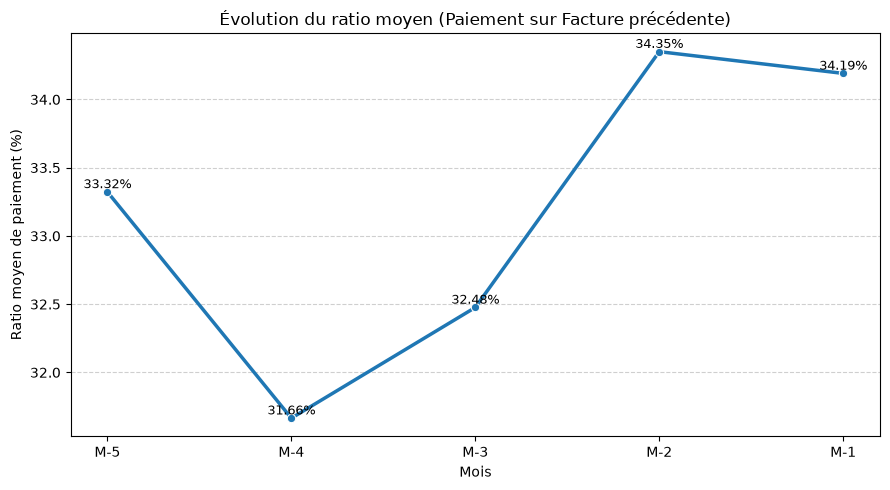

In [155]:
# 1. Ordre d'affichage : du plus ancien (M-5) au plus récent (M-1)
ordre_souhaite = [f'ratio_PAY_BILL{i}' for i in range(5, 0, -1)]

# Filtrer pour ne garder que les colonnes réellement présentes dans le dataframe
colonnes_actives = [col for col in ordre_souhaite if col in df.columns]

if len(colonnes_actives) > 0:
    # 2. Calcul des moyennes par mois
    moyennes = ratios_affichables(df, colonnes_actives).mean()

    # Libellés d'abscisse : ratio_PAY_BILL5 -> 'M-5', etc.
    labels_mois = [f"M-{col.replace('ratio_PAY_BILL', '')}" for col in colonnes_actives]

    # 3. Visualisation
    plt.figure(figsize=(9, 5))
    sns.lineplot(
        x=labels_mois,
        y=moyennes.values,
        marker='o',
        linewidth=2.5,
        color='#1f77b4'
    )

    plt.title('Évolution du ratio moyen (Paiement sur Facture précédente)')
    plt.xlabel('Mois')
    plt.ylabel('Ratio moyen de paiement (%)')

    # Ajout des valeurs textuelles
    for i, val in enumerate(moyennes.values):
        plt.text(i, val + 0.005, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print(f"Attention : Aucune des colonnes de la liste '{ordre_souhaite}' n'a été trouvée.")


**Interprétation**  
pas de tendance  
Mais la moyenne est très affectée par des valeurs aberrantes, je regarde plutot la médiane pour cette valeur :

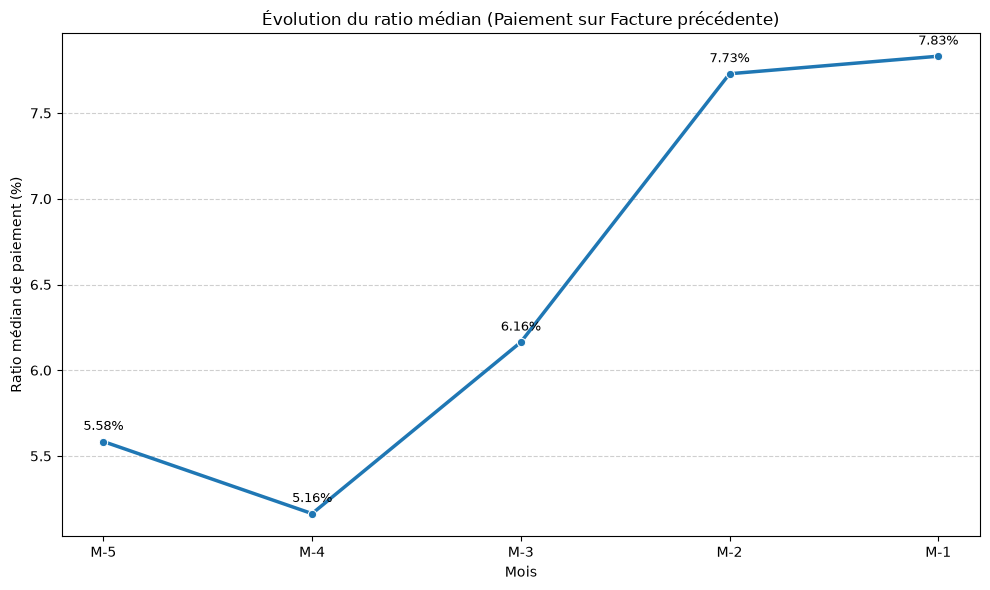

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ordre d'affichage : du plus ancien (M-5) au plus récent (M-1)
ordre_souhaite = [f'ratio_PAY_BILL{i}' for i in range(5, 0, -1)]

# Filtrer pour ne garder que les colonnes réellement présentes dans le dataframe
colonnes_actives = [col for col in ordre_souhaite if col in df.columns]

if len(colonnes_actives) > 0:
    # 2. Calcul de la médiane par période
    medianes = ratios_affichables(df, colonnes_actives).median()

    # Libellés d'abscisse : ratio_PAY_BILL5 -> 'M-5', etc.
    labels_mois = [f"M-{col.replace('ratio_PAY_BILL', '')}" for col in colonnes_actives]

    # 3. Visualisation
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        x=labels_mois,
        y=medianes.values,
        marker='o',
        linewidth=2.5,
        color='#1f77b4'
    )

    plt.title('Évolution du ratio médian (Paiement sur Facture précédente)')
    plt.xlabel('Mois')
    plt.ylabel('Ratio médian de paiement (%)')

    # Ajout des valeurs textuelles
    for i, val in enumerate(medianes.values):
        plt.text(i, val + 0.05, f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print(f"Attention : Aucune des colonnes de la liste '{ordre_souhaite}' n'a été trouvée.")


**Interprétation**  
Tendance à la hausse sur les dernier mois

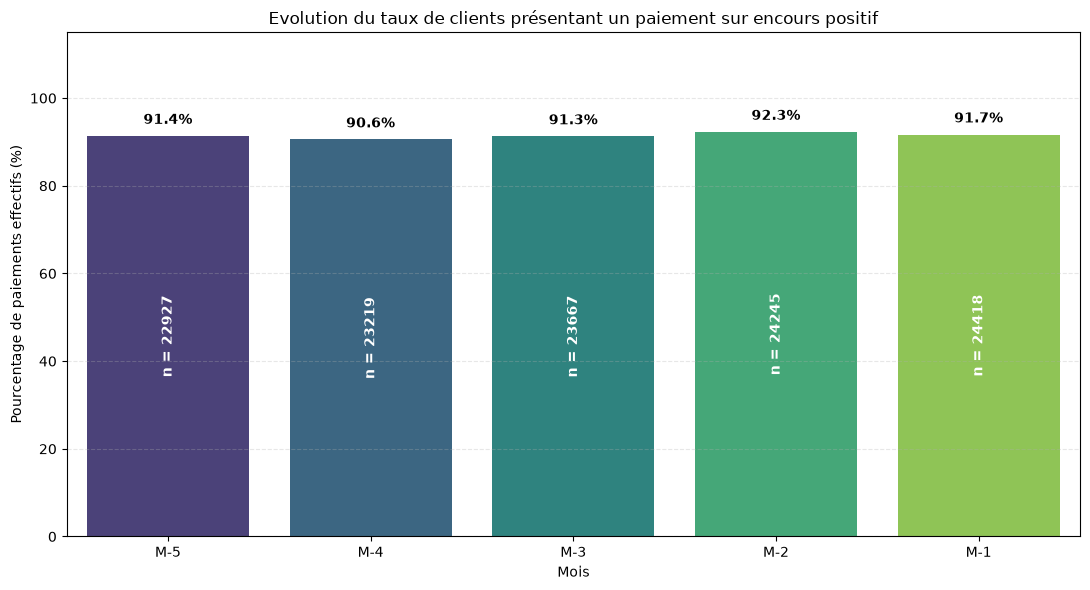

In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Appairage correct : PAY_AMTn comparé à l'encours du mois suivant BILL_AMT(n+1)
# (Du plus ancien au plus récent)
paires_chronologiques = [
    ('PAY_AMT5', 'BILL_AMT6', 'M-5'),
    ('PAY_AMT4', 'BILL_AMT5', 'M-4'),
    ('PAY_AMT3', 'BILL_AMT4', 'M-3'),
    ('PAY_AMT2', 'BILL_AMT3', 'M-2'),
    ('PAY_AMT1', 'BILL_AMT2', 'M-1')
]

proportions_pct = {}
counts_dict = {}

# 2. Calcul du taux de paiement effectif (PAY_AMTn > 0) par rapport à l'encours exigible (BILL_AMT(n+1) > 0)
for pay_col, bill_col, label in paires_chronologiques:
    if pay_col in df.columns and bill_col in df.columns:
        # Population cible : clients ayant un encours le mois précédent/référence (> 0)
        subset_avec_encours = df[df[bill_col] > 0]
        
        if len(subset_avec_encours) > 0:
            # Nombre de clients ayant effectivement versé un paiement (> 0)
            nb_payeurs = (subset_avec_encours[pay_col] > 0).sum()
            prop = (nb_payeurs / len(subset_avec_encours)) * 100
            
            proportions_pct[label] = prop
            counts_dict[label] = nb_payeurs

s_proportions = pd.Series(proportions_pct)
s_counts = pd.Series(counts_dict)

# 3. Visualisation : Pourcentage au-dessus (horizontal) et effectif (n) au centre (vertical)
if len(s_proportions) > 0:
    plt.figure(figsize=(11, 6))
    
    ax = sns.barplot(
        x=s_proportions.index, 
        y=s_proportions.values, 
        hue=s_proportions.index, 
        palette='viridis', 
        legend=False
    )
    
    for i, (label, val_pct) in enumerate(s_proportions.items()):
        val_count = s_counts[label]
        
        # A. Pourcentage horizontal au-dessus de la barre
        plt.text(
            i, val_pct + 2,                  
            f'{val_pct:.1f}%', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=10, 
            fontweight='bold'
        )
        
        # B. Nombre d'individus (n) à la verticale au milieu de la barre
        plt.text(
            i, val_pct / 2,                  
            f'n = {val_count}', 
            ha='center', 
            va='center', 
            rotation=90,                     
            color='white',                   
            fontsize=10, 
            fontweight='bold'
        )

    plt.title("Evolution du taux de clients présentant un paiement sur encours positif")
    plt.xlabel("Mois")
    plt.ylabel("Pourcentage de paiements effectifs (%)")
    
    plt.ylim(0, 115)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Il manque des colonnes valides pour réaliser l'analyse.")

**Interprétation**  
pas d'évolution sur la période

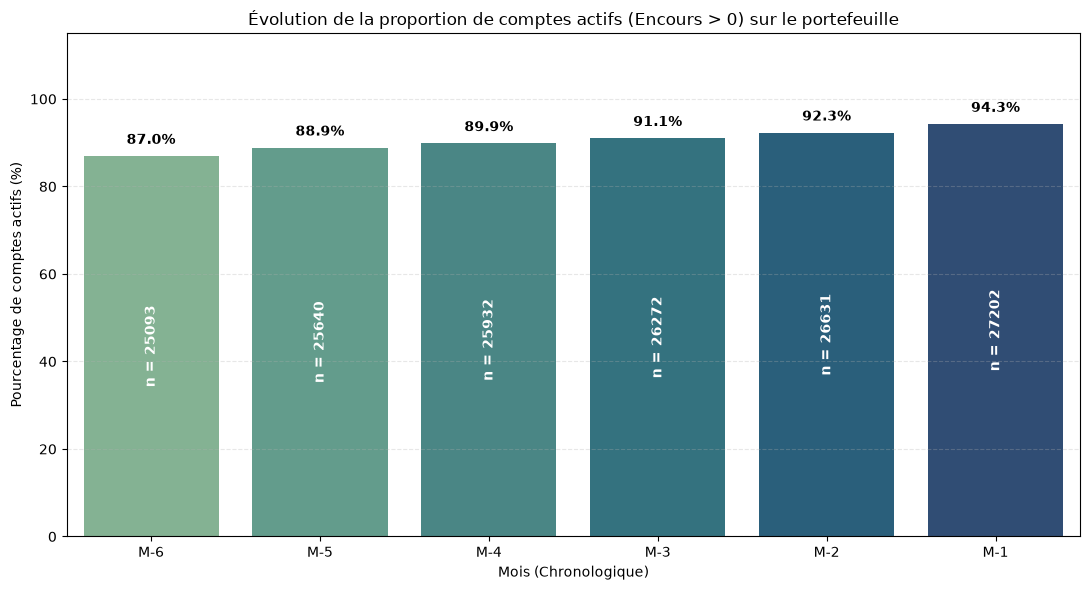

In [158]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Liste des colonnes d'encours dans l'ordre chronologique (du plus ancien au plus récent)
colonnes_bill = [
    ('BILL_AMT6', 'M-6'),
    ('BILL_AMT5', 'M-5'),
    ('BILL_AMT4', 'M-4'),
    ('BILL_AMT3', 'M-3'),
    ('BILL_AMT2', 'M-2'),
    ('BILL_AMT1', 'M-1') # ou M courant selon ta nomenclature
]

actifs_pct = {}
actifs_counts = {}
total_clients = len(df)

# 2. Calcul du taux de comptes actifs (> 0) par rapport au total des clients
for col, label in colonnes_bill:
    if col in df.columns:
        nb_actifs = (df[col] > 0).sum()
        prop = (nb_actifs / total_clients) * 100
        
        actifs_pct[label] = prop
        actifs_counts[label] = nb_actifs

s_actifs_pct = pd.Series(actifs_pct)
s_actifs_counts = pd.Series(actifs_counts)

# 3. Visualisation graphique
if len(s_actifs_pct) > 0:
    plt.figure(figsize=(11, 6))
    
    ax = sns.barplot(
        x=s_actifs_pct.index, 
        y=s_actifs_pct.values, 
        hue=s_actifs_pct.index, 
        palette='crest', # Une autre palette pour différencier du graphique précédent
        legend=False
    )
    
    for i, (label, val_pct) in enumerate(s_actifs_pct.items()):
        val_count = s_actifs_counts[label]
        
        # A. Pourcentage horizontal au-dessus de la barre
        plt.text(
            i, val_pct + 2,                  
            f'{val_pct:.1f}%', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=10, 
            fontweight='bold'
        )
        
        # B. Nombre d'individus (n) à la verticale au milieu de la barre
        plt.text(
            i, val_pct / 2,                  
            f'n = {val_count}', 
            ha='center', 
            va='center', 
            rotation=90,                     
            color='white',                   
            fontsize=10, 
            fontweight='bold'
        )

    plt.title("Évolution de la proportion de comptes actifs (Encours > 0) sur le portefeuille")
    plt.xlabel("Mois (Chronologique)")
    plt.ylabel("Pourcentage de comptes actifs (%)")
    
    plt.ylim(0, 115)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Il manque des colonnes d'encours pour réaliser l'analyse.")

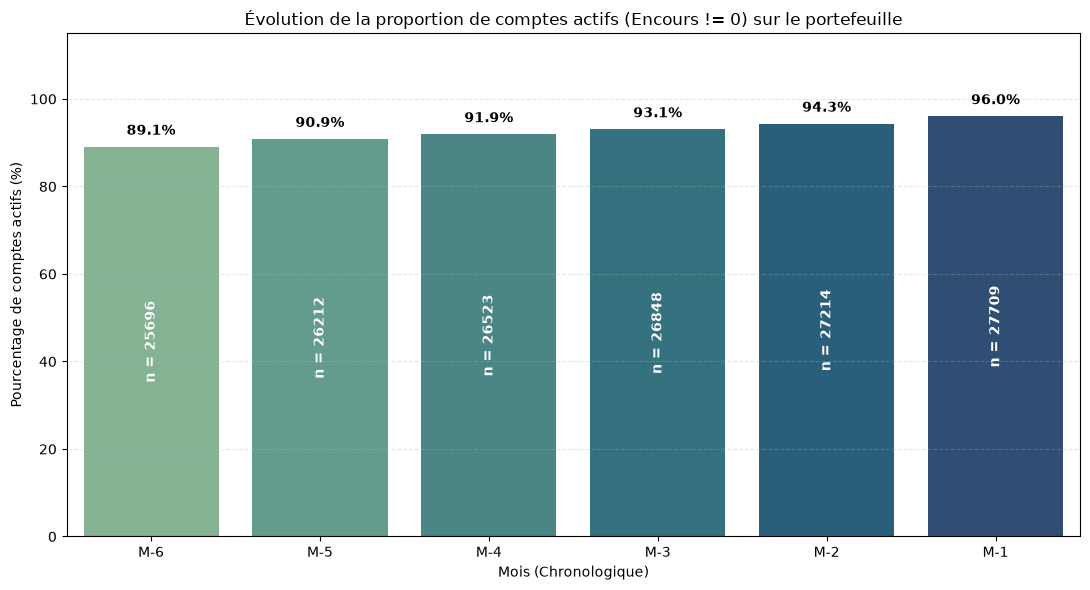

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Liste des colonnes d'encours dans l'ordre chronologique (du plus ancien au plus récent)
colonnes_bill = [
    ('BILL_AMT6', 'M-6'),
    ('BILL_AMT5', 'M-5'),
    ('BILL_AMT4', 'M-4'),
    ('BILL_AMT3', 'M-3'),
    ('BILL_AMT2', 'M-2'),
    ('BILL_AMT1', 'M-1') # ou M courant selon ta nomenclature
]

actifs_pct = {}
actifs_counts = {}
total_clients = len(df)

# 2. Calcul du taux de comptes actifs (!= 0) par rapport au total des clients
for col, label in colonnes_bill:
    if col in df.columns:
        nb_actifs = (df[col] != 0).sum()
        prop = (nb_actifs / total_clients) * 100
        
        actifs_pct[label] = prop
        actifs_counts[label] = nb_actifs

s_actifs_pct = pd.Series(actifs_pct)
s_actifs_counts = pd.Series(actifs_counts)

# 3. Visualisation graphique
if len(s_actifs_pct) > 0:
    plt.figure(figsize=(11, 6))
    
    ax = sns.barplot(
        x=s_actifs_pct.index, 
        y=s_actifs_pct.values, 
        hue=s_actifs_pct.index, 
        palette='crest', # Une autre palette pour différencier du graphique précédent
        legend=False
    )
    
    for i, (label, val_pct) in enumerate(s_actifs_pct.items()):
        val_count = s_actifs_counts[label]
        
        # A. Pourcentage horizontal au-dessus de la barre
        plt.text(
            i, val_pct + 2,                  
            f'{val_pct:.1f}%', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=10, 
            fontweight='bold'
        )
        
        # B. Nombre d'individus (n) à la verticale au milieu de la barre
        plt.text(
            i, val_pct / 2,                  
            f'n = {val_count}', 
            ha='center', 
            va='center', 
            rotation=90,                     
            color='white',                   
            fontsize=10, 
            fontweight='bold'
        )

    plt.title("Évolution de la proportion de comptes actifs (Encours != 0) sur le portefeuille")
    plt.xlabel("Mois (Chronologique)")
    plt.ylabel("Pourcentage de comptes actifs (%)")
    
    plt.ylim(0, 115)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Il manque des colonnes d'encours pour réaliser l'analyse.")

**Inteprétation**  
Hausse constante du nombre de la part de comptes actifs sur les 6 derniers mois.  
Avec un taux de paiement globalement constant, le nombre de défaillances augmente mécaniquement

In [160]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_PAY_BILL1', 'ratio_PAY_BILL2', 'ratio_PAY_BILL3',
       'ratio_PAY_BILL4', 'ratio_PAY_BILL5', 'ratio_BILL_LIMIT1',
       'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4',
       'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6', 'AGE_BUCKET',
       'LIMIT_BAL_interval', 'mean_ratio', 'ratio_mean_client',
       'ratio_max_client', 'ratio_mean_bin', 'ratio_m1_bin'],
      dtype='str')

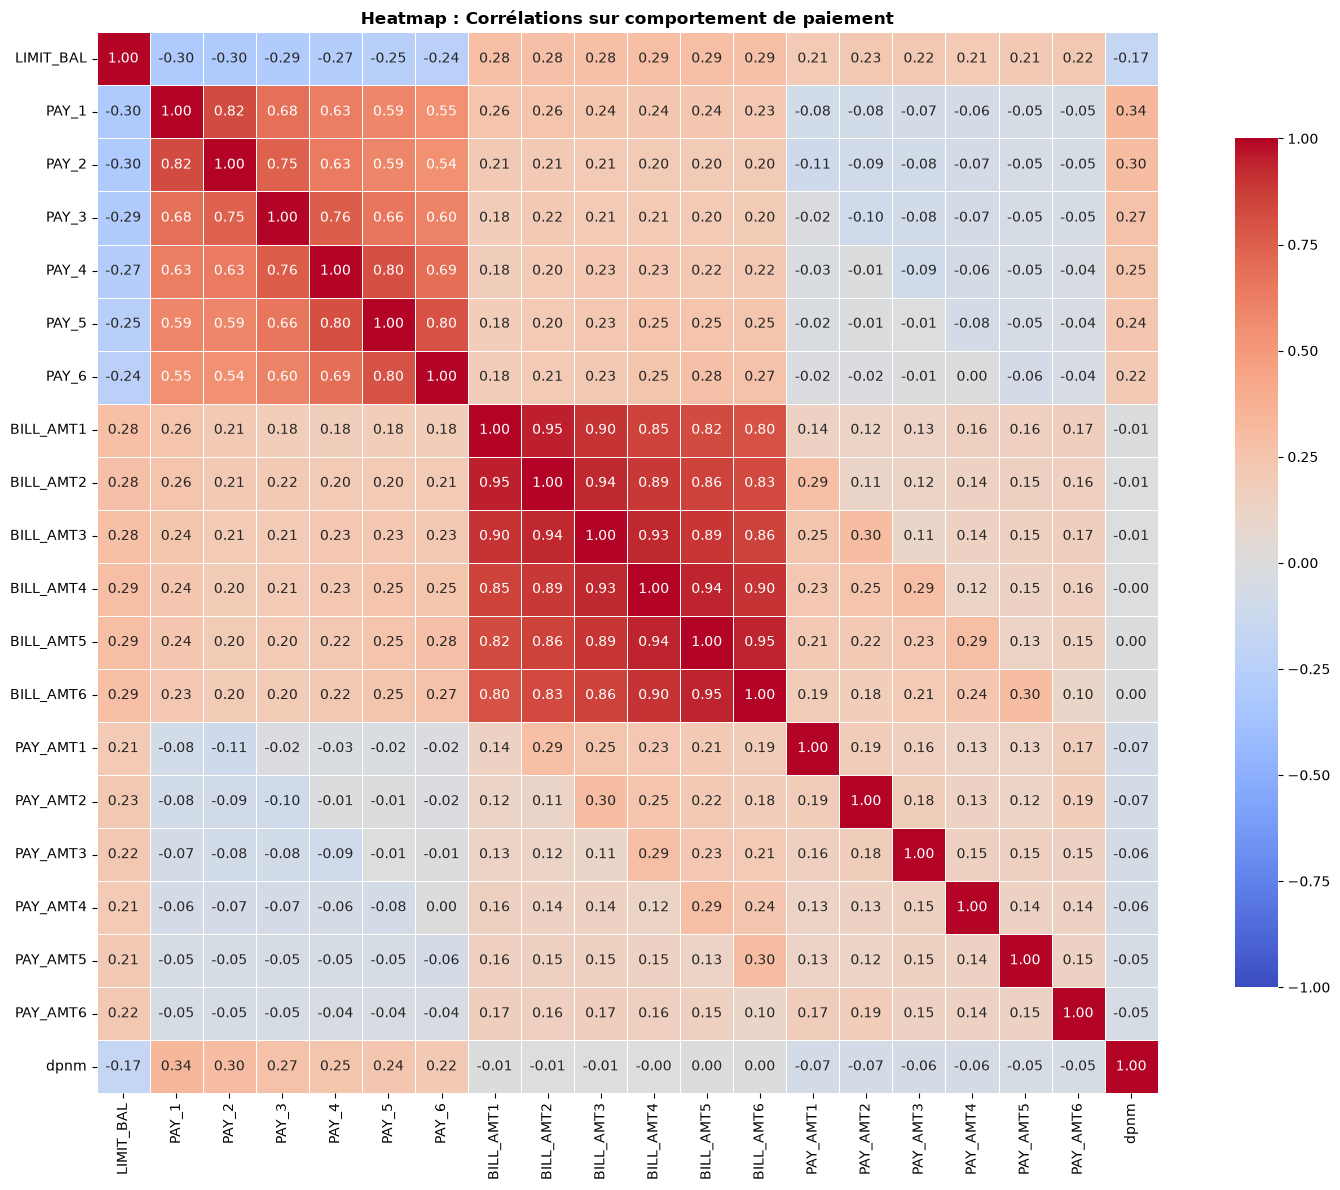

In [161]:
import seaborn as sns

# 1. Sélection des colonnes
cols = ['LIMIT_BAL', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm']
df_corr = df[cols]

# 2. Calcul de la matrice complète (sans masquage)
corr_matrix = df_corr.corr(method='pearson')

# 3. Affichage du Heatmap COMPLET
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    annot=True,       # Affiche les chiffres
    fmt=".2f",        # Format à 2 décimales
    cmap='coolwarm',  # Palette Rouge/Blanc/Bleu (positif/négatif)
    vmin=-1, vmax=1,
    square=True,      # Cases carrées
    linewidths=.5,    # Lignes fines entre les cases pour la lisibilité
    cbar_kws={"shrink": .8}
)

plt.title('Heatmap : Corrélations sur comportement de paiement', fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation**  
Aucune corrélation évidente entre les montant des encours, les montants payés et le taux de défaut.  
Corrélation progressive entre les valeurs de PAY_ et le taux de défaut, surtout à mesure qu'elles sont récentes  
Moins le plafond est important, plus le risque de défaut augmente

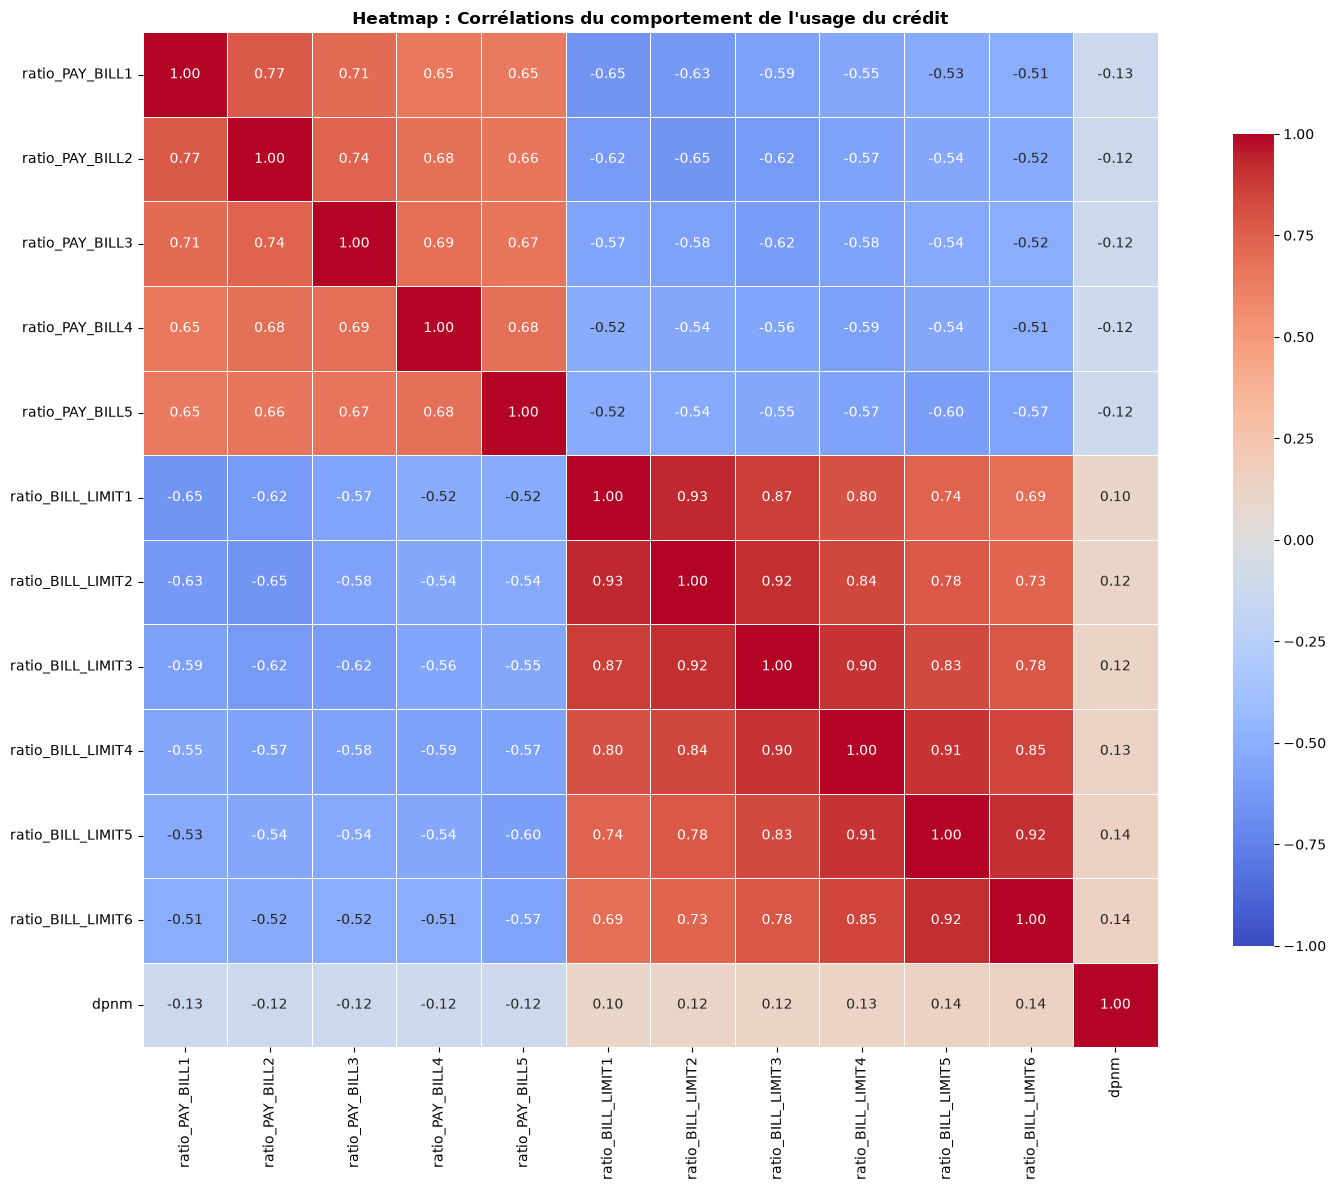

In [162]:
import seaborn as sns

# 1. Sélection des colonnes
cols = ['ratio_PAY_BILL1', 'ratio_PAY_BILL2',
       'ratio_PAY_BILL3', 'ratio_PAY_BILL4',
       'ratio_PAY_BILL5', 'ratio_BILL_LIMIT1',
       'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4',
       'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6', 'dpnm']
# Ratios de paiement affichés seulement quand une facture était exigible (corrélations calculées paire par paire)
df_corr = pd.concat([ratios_affichables(df, cols[:5]), df[cols[5:]]], axis=1)

# 2. Calcul de la matrice complète (sans masquage)
corr_matrix = df_corr.corr(method='pearson')

# 3. Affichage du Heatmap COMPLET
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    annot=True,       # Affiche les chiffres
    fmt=".2f",        # Format à 2 décimales
    cmap='coolwarm',  # Palette Rouge/Blanc/Bleu (positif/négatif)
    vmin=-1, vmax=1,
    square=True,      # Cases carrées
    linewidths=.5,    # Lignes fines entre les cases pour la lisibilité
    cbar_kws={"shrink": .8}
)

plt.title('Heatmap : Corrélations du comportement de l\'usage du crédit', fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation**  
Très faible corrélation entre les ratios de paiement, le taux d'utilisation du plafond et le défaut de paiement

In [163]:
import pandas as pd
import numpy as np

# Calculer la moyenne des ratios pour chaque période
ratio_columns = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# Calculer la moyenne par période
mean_ratios = ratios_affichables(df, ratio_columns).mean()

# Créer un DataFrame pour afficher les résultats
result_df = pd.DataFrame({
    'Période': mean_ratios.index,
    'Moyenne': mean_ratios.values
})

# Afficher le résultat
print("Répartition moyenne des ratios sur la période :")
print(result_df)

Répartition moyenne des ratios sur la période :
           Période    Moyenne
0  ratio_PAY_BILL1  34.190968
1  ratio_PAY_BILL2  34.350293
2  ratio_PAY_BILL3  32.476030
3  ratio_PAY_BILL4  31.664536
4  ratio_PAY_BILL5  33.322749


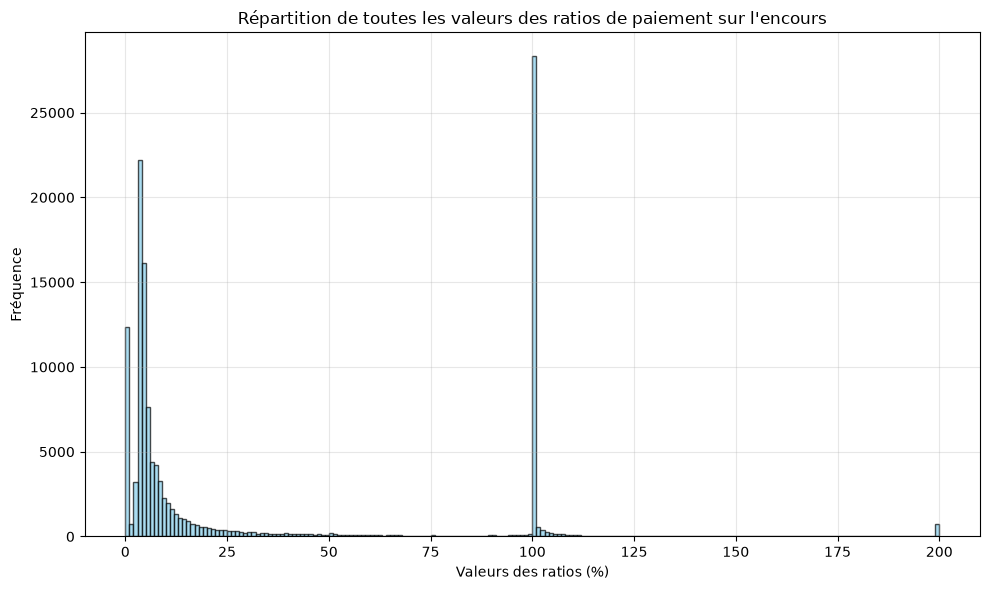

Statistiques des répartitions des valeurs :
Nombre total de valeurs : 144255
Moyenne globale : 33.2119
Médiane : 6.5650
Écart-type : 43.8201
Minimum : 0.0000
Maximum : 200.0000


In [164]:
import matplotlib.pyplot as plt

# Définir les colonnes des ratios
ratio_columns = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# Concaténer toutes les valeurs de toutes les colonnes en une seule série
all_values = ratios_affichables(df, ratio_columns).stack()

# Créer l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(all_values, bins=200, color='skyblue', edgecolor='black', alpha=0.7)

# Ajouter les étiquettes et le titre
plt.xlabel('Valeurs des ratios (%)')
plt.ylabel('Fréquence')
plt.title('Répartition de toutes les valeurs des ratios de paiement sur l\'encours')
plt.grid(True, alpha=0.3)

# Afficher le graphique
plt.tight_layout()
plt.show()

# Afficher quelques statistiques descriptives
print("Statistiques des répartitions des valeurs :")
print(f"Nombre total de valeurs : {len(all_values)}")
print(f"Moyenne globale : {all_values.mean():.4f}")
print(f"Médiane : {all_values.median():.4f}")
print(f"Écart-type : {all_values.std():.4f}")
print(f"Minimum : {all_values.min():.4f}")
print(f"Maximum : {all_values.max():.4f}")

**Interprétation**  
2 comportements de paiement distincts :
- le paiement par mensualité, le client rembourse des intérets et une partie du capital
- le paiement comptant à l'échéance, le client paie l'intégralité de ses dépenses du mois

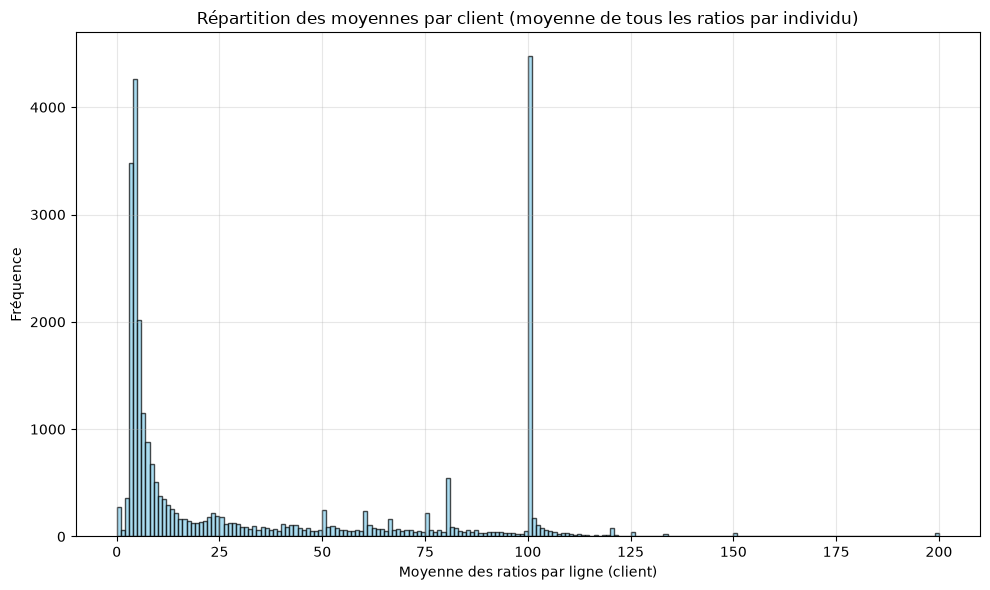

Statistiques de la répartition des moyennes par client :
Nombre total de clients : 28386
Moyenne globale des moyennes : 36.8856
Médiane : 11.3399
Écart-type : 40.1722
Minimum : 0.0000
Maximum : 200.0000


In [165]:
import matplotlib.pyplot as plt

# Définir les colonnes des ratios
ratio_columns = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# Calculer la moyenne de chaque ligne (moyenne des ratios pour chaque client)
row_means = ratios_affichables(df, ratio_columns).mean(axis=1).dropna()

# Créer l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(row_means, bins=200, color='skyblue', edgecolor='black', alpha=0.7)

# Ajouter les étiquettes et le titre
plt.xlabel('Moyenne des ratios par ligne (client)')
plt.ylabel('Fréquence')
plt.title('Répartition des moyennes par client (moyenne de tous les ratios par individu)')
plt.grid(True, alpha=0.3)

# Afficher le graphique
plt.tight_layout()
plt.show()

# Afficher quelques statistiques descriptives
print("Statistiques de la répartition des moyennes par client :")
print(f"Nombre total de clients : {len(row_means)}")
print(f"Moyenne globale des moyennes : {row_means.mean():.4f}")
print(f"Médiane : {row_means.median():.4f}")
print(f"Écart-type : {row_means.std():.4f}")
print(f"Minimum : {row_means.min():.4f}")
print(f"Maximum : {row_means.max():.4f}")

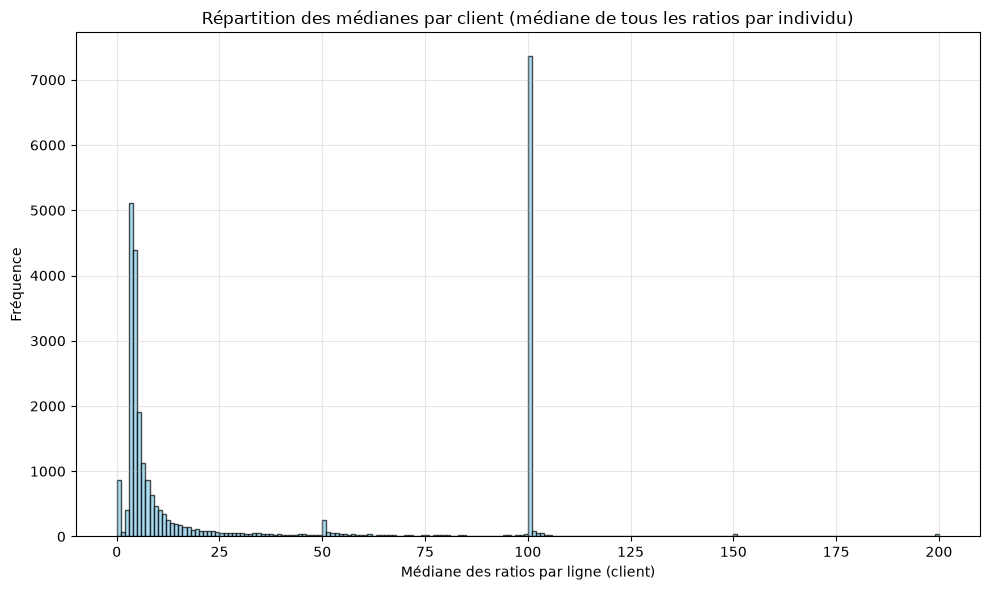

Statistiques de la répartition des moyennes par client :
Nombre total de clients : 28386
Moyenne globale des moyennes : 36.1301
Médiane : 7.3497
Écart-type : 43.0990
Minimum : 0.0000
Maximum : 200.0000


In [166]:
import matplotlib.pyplot as plt

# Définir les colonnes des ratios
ratio_columns = [
    'ratio_PAY_BILL1',
    'ratio_PAY_BILL2', 
    'ratio_PAY_BILL3', 
    'ratio_PAY_BILL4', 
    'ratio_PAY_BILL5'
]

# Calculer la médiane de chaque ligne (médiane des ratios pour chaque client)
# Colonne créée : définition unique (docs/colonnes_creees.md)
df['ratio_PAY_to_BILL_median'] = df[ratio_columns].median(axis=1)
# Graphique : médiane des seuls mois avec une facture exigible
row_medians = ratios_affichables(df, ratio_columns).median(axis=1).dropna()

# Enregistrer la médiane dans une nouvelle colonne du DataFrame

# Créer l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(row_medians, bins=200, color='skyblue', edgecolor='black', alpha=0.7)

# Ajouter les étiquettes et le titre
plt.xlabel('Médiane des ratios par ligne (client)')
plt.ylabel('Fréquence')
plt.title('Répartition des médianes par client (médiane de tous les ratios par individu)')
plt.grid(True, alpha=0.3)

# Afficher le graphique
plt.tight_layout()
plt.show()

# Afficher quelques statistiques descriptives
print("Statistiques de la répartition des moyennes par client :")
print(f"Nombre total de clients : {len(row_medians)}")
print(f"Moyenne globale des moyennes : {row_medians.mean():.4f}")
print(f"Médiane : {row_medians.median():.4f}")
print(f"Écart-type : {row_medians.std():.4f}")
print(f"Minimum : {row_medians.min():.4f}")
print(f"Maximum : {row_medians.max():.4f}")

In [167]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_PAY_BILL1', 'ratio_PAY_BILL2', 'ratio_PAY_BILL3',
       'ratio_PAY_BILL4', 'ratio_PAY_BILL5', 'ratio_BILL_LIMIT1',
       'ratio_BILL_LIMIT2', 'ratio_BILL_LIMIT3', 'ratio_BILL_LIMIT4',
       'ratio_BILL_LIMIT5', 'ratio_BILL_LIMIT6', 'AGE_BUCKET',
       'LIMIT_BAL_interval', 'mean_ratio', 'ratio_mean_client',
       'ratio_max_client', 'ratio_mean_bin', 'ratio_m1_bin',
       'ratio_PAY_to_BILL_median'],
      dtype='str')

**Interprétation**  
En regardant le comportement médian par client, je constate la constance majoritaire du comportement.  
Les 2 types d'utilisation de cartes ressortent ici aussi en terme de comportement individuel régulier.  
Cela fait un partage de comportement à insérer dans le ML.

In [168]:
import pandas as pd

# 1. Définition des listes de colonnes
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5']
bill_cols = ['BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Total global de -2 dans le dataset pour chaque colonne
count_neg2_total = df[pay_cols].eq(-2).sum()

# 2. Création de masques exclusifs (non chevauchants)
# Groupe 1 : Ratio < 25
mask_g1 = df['ratio_PAY_to_BILL_median'] < 25

# Groupe 2 : Ratio entre 25 et 90 (inclus) ET pas de ratio < 25
mask_g2 = (df['ratio_PAY_to_BILL_median'] >= 25) & (df['ratio_PAY_to_BILL_median'] <= 90)

# Groupe 3 : Ratio > 90
mask_g3 = df['ratio_PAY_to_BILL_median'] > 90

print("=== Répartition exclusive des '-2' selon le ratio ===")

# Calcul pour le Groupe 1 (< 25)
count_g1 = df.loc[mask_g1, pay_cols].eq(-2).sum()
prop_g1 = (count_g1 / count_neg2_total) * 100

# Calcul pour le Groupe 2 (25 - 90)
count_g2 = df.loc[mask_g2, pay_cols].eq(-2).sum()
prop_g2 = (count_g2 / count_neg2_total) * 100

# Calcul pour le Groupe 3 (> 90)
count_g3 = df.loc[mask_g3, pay_cols].eq(-2).sum()
prop_g3 = (count_g3 / count_neg2_total) * 100

# Affichage propre
for col in pay_cols:
    print(f"\n--- {col} ---")
    print(f"Ratio < 25 : {prop_g1[col]:.2f}%")
    print(f"Ratio 25-90 : {prop_g2[col]:.2f}%")
    print(f"Ratio > 90 : {prop_g3[col]:.2f}%")
    print(f"Somme : {prop_g1[col] + prop_g2[col] + prop_g3[col]:.2f}%")

=== Répartition exclusive des '-2' selon le ratio ===

--- PAY_1 ---
Ratio < 25 : 4.62%
Ratio 25-90 : 2.09%
Ratio > 90 : 93.28%
Somme : 100.00%

--- PAY_2 ---
Ratio < 25 : 3.59%
Ratio 25-90 : 1.53%
Ratio > 90 : 94.88%
Somme : 100.00%

--- PAY_3 ---
Ratio < 25 : 1.74%
Ratio 25-90 : 0.48%
Ratio > 90 : 97.78%
Somme : 100.00%

--- PAY_4 ---
Ratio < 25 : 1.33%
Ratio 25-90 : 0.44%
Ratio > 90 : 98.22%
Somme : 100.00%

--- PAY_5 ---
Ratio < 25 : 1.37%
Ratio 25-90 : 0.48%
Ratio > 90 : 98.15%
Somme : 100.00%


Qu'en est il du dpnm selon le type d'usage de la carte ?

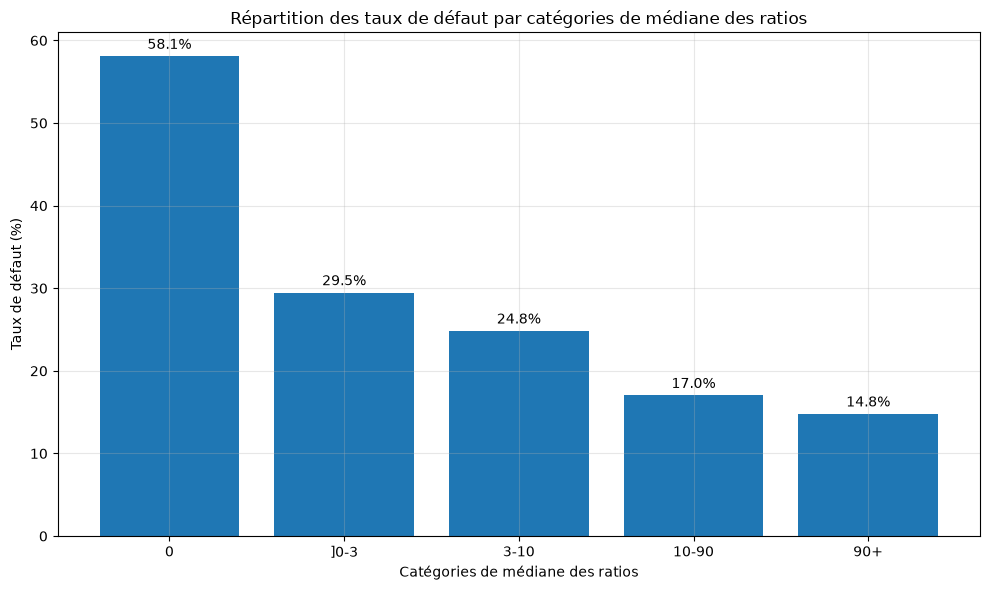

Statistiques de la répartition des taux de DPNM :
Nombre total de clients : 28386

Taux de DPNM par catégorie :
0: 58.08% (453/780 clients défauts/780 total)
]0-3: 29.46% (165/560 clients défauts/560 total)
3-10: 24.83% (3603/14513 clients défauts/14513 total)
10-90: 17.03% (767/4505 clients défauts/4505 total)
90+: 14.79% (1187/8028 clients défauts/8028 total)

Statistiques des médianes par client :
Moyenne des médianes : 36.1301
Médiane des médianes : 7.3497
Écart-type : 43.0990
Minimum : 0.0000
Maximum : 200.0000


In [169]:
import matplotlib.pyplot as plt
import numpy as np

# Définir les colonnes des ratios
ratio_columns = [
'ratio_PAY_BILL1',
'ratio_PAY_BILL2', 
'ratio_PAY_BILL3', 
'ratio_PAY_BILL4', 
'ratio_PAY_BILL5'
]

# Calculer la médiane de chaque ligne (médiane des ratios pour chaque client)
row_medians = ratios_affichables(df, ratio_columns).median(axis=1)

# Créer les catégories DPNM
def categorize_dpnms(median_value):
    if median_value == 0:
        return '0'
    elif median_value < 3 :
        return ']0-3'
    elif median_value < 10:
        return '3-10'
    elif median_value < 90:
        return '10-90'
    else:
        return '90+'

# Appliquer la catégorisation
# Clients sans aucune facture exigible sur la période : pas de médiane affichable, exclus
categories = row_medians.apply(categorize_dpnms).where(row_medians.notna())

# Calculer les taux de DPNM pour chaque catégorie
category_counts = categories.value_counts()
total_clients = int(row_medians.notna().sum())

# Calculer le taux de défaut (DPNM) par catégorie
dpmn_rates = {}
dpnm_counts = {}

for category in ['0',']0-3', '3-10', '10-90', '90+']:
    # Filtrer les clients de cette catégorie
    mask = categories == category
    clients_in_category = df[mask]
    
    # Calculer le taux de défaut (nombre de défauts / nombre total dans la catégorie)
    if len(clients_in_category) > 0:
        dpnm_count = clients_in_category['dpnm'].sum()  # Nombre de défauts
        dpnm_rate = (dpnm_count / len(clients_in_category)) * 100
        dpnm_counts[category] = dpnm_count
    else:
        dpnm_rate = 0
        dpnm_counts[category] = 0
    
    dpmn_rates[category] = dpnm_rate

# Créer le graphique en barres pour les taux de DPNM
plt.figure(figsize=(10, 6))
categories_list = ['0',']0-3', '3-10', '10-90', '90+']
rates = [dpmn_rates[cat] for cat in categories_list]

bars = plt.bar(categories_list, rates)

# Ajouter les étiquettes et le titre
plt.xlabel('Catégories de médiane des ratios')
plt.ylabel('Taux de défaut (%)')
plt.title('Répartition des taux de défaut par catégories de médiane des ratios')
plt.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (bar, rate) in enumerate(zip(bars, rates)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Afficher les statistiques détaillées
print("Statistiques de la répartition des taux de DPNM :")
print(f"Nombre total de clients : {total_clients}")
print("\nTaux de DPNM par catégorie :")
for category, rate in dpmn_rates.items():
    count = category_counts.get(category, 0)
    dpnm_count = dpnm_counts[category]
    print(f"{category}: {rate:.2f}% ({dpnm_count}/{count} clients défauts/{count} total)")

# Afficher également les statistiques sur les médianes
print("\nStatistiques des médianes par client :")
print(f"Moyenne des médianes : {row_medians.mean():.4f}")
print(f"Médiane des médianes : {row_medians.median():.4f}")
print(f"Écart-type : {row_medians.std():.4f}")
print(f"Minimum : {row_medians.min():.4f}")
print(f"Maximum : {row_medians.max():.4f}")

**Interprétation**  
Le type d'usage de la carte a clairement un impact sur le taux de défaut :
- ceux qui ont l'habitude de ne pas payer sont naturellement plus enclins à etre en défaut de paiement
- ceux qui utilisent la carte essentiellement à crédit  ont une taux de défaut plus haut que la moyenne et 2 fois plus important que ceux qui utilisent la carte comme un moyen de paiement standard (différé fin de mois)
- Plus le client a tendance à payer une grosse partie de ce qu'il doit chaque mois moins il a tendance à avoir un impayé

### Population contentieuse (CTX) : restitution de la définition retenue
La population contentieuse est définie et validée dans `05_02_EDA_contentieux.ipynb` (définition 2, révisée le 27/09/2026). Cette section en reprend les résultats pour la présentation, **sans modifier la règle**.

La règle en langage simple :
- un client est au contentieux (CTX) à M s'il est toujours en retard (code 2 ou plus) au dernier mois connu (M-1) sans avoir réglé sa facture ;
- dans l'historique, un passage au CTX suppose au moins deux mois de retard d'affilée ; un retard isolé suivi d'un retour à la normale est un retard régularisé ;
- les codes de retard posés alors qu'aucune facture n'était due ne comptent pas (faux codage, compte récemment réactivé mis sous surveillance) ;
- un client en retard en M-1 qui a payé au moins 90 % de sa facture (en M-1 ou en M-2) est considéré comme régularisé.

Les clients au CTX sont retirés du ML et prédits en défaut par la règle ; les autres restent dans le ML avec des indicateurs de leur historique.
Périmètre : S12 (encours positif en M-1, plafond <= 500 000 NT$), comme le ML.

In [170]:
# Fonctions recopiées de 05_02_EDA_contentieux (corriger_faux_codage : section 3, recodage_pay1 : section 6.1,
# statut_ctx_regle2 : section 6 ; version révisée du 27/09/2026, recodage du mois de transition révisé le 30/09/2026) :
# ne pas les modifier ici, toute évolution de la règle se fait dans 05_02 puis est recopiée.
pay_cols = [f'PAY_{i}' for i in range(1, 7)]

def corriger_faux_codage(d, neutraliser_endormis=False):
    # Faux 2 : entrée au CTX (PAY_m >= 2 alors que PAY_(m+1) < 2) alors que la facture exigible,
    # BILL_AMT(m+1), est nulle ou négative
    # - compte endormi (ni paiement le mois précédent, ni encours 2 mois avant) : compte récent sous surveillance ;
    #   code 2 conservé (règle 1), ou neutralisé pour le calcul du CTX si neutraliser_endormis=True (définition 2 révisée)
    # - client qui venait de payer ou avait un encours : faux codage, les codes >= 2 posés sur une facture nulle
    #   sont remplacés par le dernier code sain précédant l'entrée
    codes = d[pay_cols].copy()
    faux_codage = pd.Series(False, index=d.index)
    surveillance = pd.Series(False, index=d.index)
    for m in range(1, 6):
        faux_2 = (d[f'PAY_{m}'] >= 2) & (d[f'PAY_{m+1}'] < 2) & (d[f'BILL_AMT{m+1}'] <= 0)
        paiement_avant = d[f'PAY_AMT{m+1}'] > 0
        # encours 2 mois avant le 2 non observable pour une entrée en M-5
        encours_avant = d[f'BILL_AMT{m+2}'] > 0 if m + 2 <= 6 else pd.Series(False, index=d.index)
        fc = faux_2 & (paiement_avant | encours_avant)
        surveillance |= faux_2 & ~fc
        faux_codage |= fc
        # Neutralisation de la série de codes >= 2 sur facture nulle, à partir du mois d'entrée
        # (faux codage toujours ; compte endormi seulement si neutraliser_endormis=True)
        a_corriger = (faux_2 if neutraliser_endormis else fc).copy()
        for k in range(m, 0, -1):
            a_corriger &= (d[f'PAY_{k}'] >= 2) & (d[f'BILL_AMT{k+1}'] <= 0)
            codes.loc[a_corriger, f'PAY_{k}'] = d.loc[a_corriger, f'PAY_{m+1}']
    d_corrige = d.copy()
    d_corrige[pay_cols] = codes
    return d_corrige, faux_codage, surveillance

def recodage_pay1(d):
    # Mois de transition : sortie apparente du CTX entre M-2 et M-1 (PAY_2 >= 2, PAY_1 <= 1)
    transition = (d['PAY_2'] >= 2) & (d['PAY_1'] <= 1)
    # Ratio de paiement de M-1 sur la facture précédente (en %), 0 si pas de facture positive
    ratio = (d['PAY_AMT1'] / d['BILL_AMT2'].where(d['BILL_AMT2'] > 0) * 100).fillna(0)
    # Aucun paiement sur 2 mois (décalage d'enregistrement des paiements)
    sans_paiement_2_mois = (d['PAY_AMT1'] == 0) & (d['PAY_AMT2'] == 0)
    # Absence de paiement significative seulement si une facture était exigible les 2 mois (BILL_AMT3 en M-2, BILL_AMT2 en M-1)
    factures_exigibles = (d['BILL_AMT3'] > 0) & (d['BILL_AMT2'] > 0)
    # Code d'avant le retard : premier code < 2 avant la série de retards (PAY_3, PAY_4...) ; 0 si la série remonte jusqu'à M-6 ;
    # -2 remplacé par -1 (un client qui avait une dette ne sort pas en « pas de consommation »), code > 0 ramené à 0 (section 6.1)
    code_avant = pd.Series(0, index=d.index)
    a_chercher = pd.Series(True, index=d.index)
    for k in range(3, 7):
        trouve = a_chercher & (d[f'PAY_{k}'] < 2)
        code_avant[trouve] = d.loc[trouve, f'PAY_{k}']
        a_chercher &= ~trouve
    code_avant = code_avant.clip(upper=0).replace(-2, -1)

    pay1_recode = np.select(
        [transition & sans_paiement_2_mois & factures_exigibles, transition & (ratio >= 90)],
        [2, code_avant],
        default=d['PAY_1'],
    )
    return pd.Series(pay1_recode, index=d.index)


def statut_ctx_regle2(d):
    # 1. Correction des faux codages (identique à la règle 1), 2. recodage du mois de transition (révisé, section 6.1)
    #    (révision : les codes 2 posés sur facture nulle d'un compte endormi sont neutralisés, flag SURVEILLANCE_RECENTE conservé)
    d_corrige, faux_codage, surveillance = corriger_faux_codage(d, neutraliser_endormis=True)
    pay1 = recodage_pay1(d_corrige)
    codes = d_corrige[pay_cols].copy()
    codes['PAY_1'] = pay1

    # 3. Retard payé : PAY_1 >= 2 mais facture payée à 90 % ou plus en M-1 ou en M-2
    ratio_m1 = (d['PAY_AMT1'] / d['BILL_AMT2'].where(d['BILL_AMT2'] > 0) * 100).fillna(0)
    ratio_m2 = (d['PAY_AMT2'] / d['BILL_AMT3'].where(d['BILL_AMT3'] > 0) * 100).fillna(0)
    retard_paye = (pay1 >= 2) & ((ratio_m1 >= 90) | (ratio_m2 >= 90))
    #    Retard payé qui termine une série (PAY_2 >= 2) : passage au CTX avéré, sortie présumée en M
    #    Retard payé isolé (PAY_2 < 2) : régularisation présumée d'un retard isolé
    retard_paye_serie = retard_paye & (codes['PAY_2'] >= 2)
    retard_paye_isole = retard_paye & ~retard_paye_serie

    # 4. Historique (séries de codes >= 2 terminées avant M-1) :
    #    série d'au moins 2 mois = passage au CTX ; 2 isolé = retard régularisé ;
    #    2 isolé en M-6 = passage au CTX par défaut (M-7 inconnu)
    retard = (codes >= 2).values
    passage_ctx = np.zeros(len(d), bool)
    retard_regularise = np.zeros(len(d), bool)
    mois_sortie = np.full(len(d), -1.0)
    mois_regularisation = np.full(len(d), -1.0)
    for i, r in enumerate(retard):
        k = 1
        while k < 6:
            if r[k] and not r[k - 1]:
                fin = k
                while fin + 1 < 6 and r[fin + 1]:
                    fin += 1
                # k = mois du retour sous 2 (1 = M-1), séries parcourues de la plus récente à la plus ancienne
                if fin > k or fin == 5:
                    if not passage_ctx[i]:
                        mois_sortie[i] = k
                    passage_ctx[i] = True
                else:
                    if not retard_regularise[i]:
                        mois_regularisation[i] = k
                    retard_regularise[i] = True
                k = fin + 1
            else:
                k += 1
    passage_ctx = pd.Series(passage_ctx, index=d.index)
    retard_regularise = pd.Series(retard_regularise, index=d.index)

    statut = pd.Series(np.select(
        [retard_paye, pay1 >= 2, passage_ctx, retard_regularise],
        ['Retard considéré régularisé M-1', 'CTX', 'Sorti', 'Retard régularisé'],
        default='Jamais CTX',
    ), index=d.index)

    duree = (codes >= 2).cumprod(axis=1).sum(axis=1)
    sous_statut = statut.copy()
    sous_statut[(statut == 'CTX') & (duree == 6)] = 'CTX 6 mois'
    sous_statut[(statut == 'CTX') & (duree.between(2, 5))] = 'CTX 2 à 5 mois'
    sous_statut[(statut == 'CTX') & (duree == 1)] = 'CTX entrée en M-1'
    sous_statut[retard_paye_serie] = 'Retard considéré régularisé M-1 (série)'
    sous_statut[retard_paye_isole] = 'Retard considéré régularisé M-1 (isolé)'

    # FLAG_CTX = 1 : client au CTX à M ou passé par le CTX ; MOIS_SORTIE_CTX = -1 : pas de sortie (au CTX à M ou jamais au CTX)
    # -> client au CTX à M = FLAG_CTX = 1 et MOIS_SORTIE_CTX = -1 (retiré du dataset ML)
    mois_sortie = pd.Series(mois_sortie, index=d.index)
    mois_sortie[statut == 'CTX'] = -1
    # Retard payé en série = sortie du CTX présumée en M : MOIS_SORTIE_CTX = 0 (tête d'échelle)
    mois_sortie[retard_paye_serie] = 0
    # Retard payé isolé = régularisation présumée au plus tard en M : MOIS_SORTIE_RETARD = 0 (tête d'échelle)
    mois_regularisation = pd.Series(mois_regularisation, index=d.index)
    mois_regularisation[retard_paye_isole] = 0
    mois_regularisation[statut == 'CTX'] = np.nan
    retard_regularise = retard_regularise | retard_paye_isole

    return pd.DataFrame({
        'PAY_1_recode': pay1,
        'STATUT_CTX': statut,
        'SOUS_STATUT_CTX': sous_statut,
        'MOIS_SORTIE_CTX': mois_sortie,
        'FLAG_CTX': (passage_ctx | (statut == 'CTX') | retard_paye_serie).astype(int),
        'MOIS_SORTIE_RETARD': mois_regularisation,
        'FLAG_RETARD': (retard_regularise & (statut != 'CTX')).astype(int),
        'SURVEILLANCE_RECENTE': surveillance.astype(int),
        'FAUX_CODAGE': faux_codage.astype(int),
    })


In [171]:
df_s12 = df[(df['BILL_AMT1'] > 0) & (df['LIMIT_BAL'] <= 500000)].copy()
statuts_ctx = statut_ctx_regle2(df_s12)

ordre_statuts = ['CTX', 'Retard considéré régularisé M-1', 'Sorti', 'Retard régularisé', 'Jamais CTX']
tableau_ctx = (
    df_s12.groupby(statuts_ctx['STATUT_CTX'])['dpnm']
    .agg(nb_clients='count', nb_defauts='sum', taux_defaut=lambda x: x.mean() * 100)
    .reindex(ordre_statuts)
)
tableau_ctx['part_clients'] = tableau_ctx['nb_clients'] / len(df_s12) * 100
tableau_ctx['part_defauts'] = tableau_ctx['nb_defauts'] / df_s12['dpnm'].sum() * 100
display(tableau_ctx.round(2).rename_axis('Statut à M'))

ctx = statuts_ctx['STATUT_CTX'] == 'CTX'
print(f"Taux de défaut du périmètre S12 : {df_s12['dpnm'].mean() * 100:.2f} %")
print(f"Taux de défaut sans le CTX (population laissée au ML) : {df_s12.loc[~ctx, 'dpnm'].mean() * 100:.2f} %")


,nb_clients,nb_defauts,taux_defaut,part_clients,part_defauts
Statut à M,,,,,
CTX,3004,2117,70.47,11.04,35.45
Retard considéré régularisé M-1,182,81,44.51,0.67,1.36
Sorti,2571,948,36.87,9.45,15.87
Retard régularisé,2258,604,26.75,8.30,10.11
Jamais CTX,19187,2222,11.58,70.54,37.21


Taux de défaut du périmètre S12 : 21.95 %
Taux de défaut sans le CTX (population laissée au ML) : 15.93 %


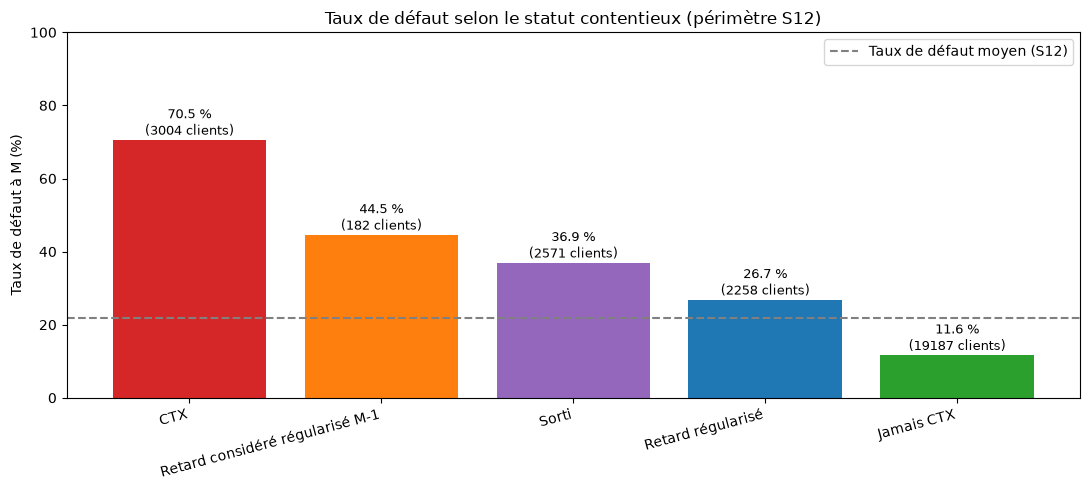

In [172]:
fig, ax = plt.subplots(figsize=(11, 5))
couleurs = ['#d62728', '#ff7f0e', '#9467bd', '#1f77b4', '#2ca02c']
bars = ax.bar(tableau_ctx.index, tableau_ctx['taux_defaut'], color=couleurs)
ax.axhline(df_s12['dpnm'].mean() * 100, color='grey', linestyle='--', label='Taux de défaut moyen (S12)')

for bar, taux, nb in zip(bars, tableau_ctx['taux_defaut'], tableau_ctx['nb_clients']):
    ax.text(bar.get_x() + bar.get_width() / 2, taux + 1.5, f"{taux:.1f} %\n({int(nb)} clients)",
            ha='center', fontsize=9)

ax.set_ylabel('Taux de défaut à M (%)')
ax.set_title('Taux de défaut selon le statut contentieux (périmètre S12)')
ax.set_ylim(0, 100)
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


**Interprétation**
- Les clients au CTX ont un taux de défaut très supérieur à tous les autres statuts : les prédire en défaut par une règle métier est justifié.
- En les retirant, le taux de défaut de la population laissée au ML baisse nettement : le ML traite une population plus homogène, mais avec moins de signal.
- Le risque décroît ensuite des clients régularisés en M-1 aux clients sortis du CTX, puis aux retards isolés régularisés et aux clients jamais passés par le CTX. Cette gradation est transmise au ML par les indicateurs d'historique (`FLAG_CTX`, `MOIS_SORTIE_CTX`, `FLAG_RETARD`, `MOIS_SORTIE_RETARD`, `SURVEILLANCE_RECENTE`, `FAUX_CODAGE`).
- Contrepartie assumée : une partie des clients au CTX ne fera pas défaut mais sera prédite en défaut par la règle.